In [69]:
import pandas as pd
import numpy as np
import warnings
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

# 1. Load the data
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True) # m^3/s
df_sim = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)  # mm/day
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0) # Stations as index

# Find the common stations across all three datasets
common_stations = list(set(df_obs.columns) & set(df_sim.columns) & set(df_attr.index))
print(f"Found {len(common_stations)} common stations.")

# Filter datasets to keep only common stations
df_obs = df_obs[common_stations]
df_sim = df_sim[common_stations]
df_attr = df_attr.loc[common_stations]

# 2. Convert ground truth units from m^3/s to mm/day
for station in common_stations:
    area_km2 = df_attr.loc[station, 'basin_area_km2']
    df_obs[station] = df_obs[station] * (86.4 / area_km2)

# 3. Align dates (1980-2022 vs 2013-2022)
df_obs, df_sim = df_obs.align(df_sim, join='inner')

# Identify August dates for the PBIAS August calculation
august_mask = df_obs.index.month == 8

# 4. Define Metric Functions
def calculate_nse(obs, sim):
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs_valid = obs[valid_mask]
    sim_valid = sim[valid_mask]
    if len(obs_valid) == 0 or np.sum((obs_valid - np.mean(obs_valid)) ** 2) == 0:
        return np.nan
    numerator = np.sum((obs_valid - sim_valid) ** 2)
    denominator = np.sum((obs_valid - np.mean(obs_valid)) ** 2)
    return 1 - (numerator / denominator)

def calculate_kge(obs, sim):
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs_valid = obs[valid_mask]
    sim_valid = sim[valid_mask]
    
    if len(obs_valid) == 0 or np.std(obs_valid) == 0 or np.mean(obs_valid) == 0:
        return np.nan
        
    # Suppress Pearson R warnings for near-constant arrays
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r = np.corrcoef(obs_valid, sim_valid)[0, 1]
        
    if np.isnan(r):
        return np.nan
        
    alpha = np.std(sim_valid) / np.std(obs_valid)
    beta = np.mean(sim_valid) / np.mean(obs_valid)
    
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    return kge

def calculate_pbias(obs, sim):
    """Calculates Percent Bias. Positive values indicate model overestimation."""
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs_valid = obs[valid_mask]
    sim_valid = sim[valid_mask]
    
    if len(obs_valid) == 0 or np.sum(obs_valid) == 0:
        return np.nan
        
    pbias = 100 * np.sum(sim_valid - obs_valid) / np.sum(obs_valid)
    return pbias

# 5. Calculate Metrics for each station
results = []
for station in common_stations:
    obs_vals = df_obs[station].values
    sim_vals = df_sim[station].values
    
    # Isolate August values
    obs_aug = df_obs.loc[august_mask, station].values
    sim_aug = df_sim.loc[august_mask, station].values
    
    results.append({
        'Station': station,
        'NSE': calculate_nse(obs_vals, sim_vals),
        'KGE': calculate_kge(obs_vals, sim_vals),
        'PBIAS': calculate_pbias(obs_vals, sim_vals),
        'PBIAS_Aug': calculate_pbias(obs_aug, sim_aug)
    })

# Convert to DataFrame for easy stats
df_results = pd.DataFrame(results).set_index('Station')

# 6. Define a reporting helper function
def print_summary_stats(df, title):
    print(f"\n{'='*40}")
    print(f"{title.center(40)}")
    print(f"{'='*40}")
    
    metrics = ['NSE', 'KGE', 'PBIAS', 'PBIAS_Aug']
    
    for metric in metrics:
        series = df[metric].dropna()
        print(f"\n--- {metric} ---")
        if series.empty:
            print("No valid data for this metric.")
            continue
            
        print(f"Mean:   {series.mean():.3f}")
        print(f"Median: {series.median():.3f}")
        print(f"Max:    {series.max():.3f}")
        print(f"Min:    {series.min():.3f}")
        print(f"Q1 (25th): {series.quantile(0.25):.3f}")
        print(f"Q2 (50th): {series.quantile(0.50):.3f}")
        print(f"Q3 (75th): {series.quantile(0.75):.3f}")

# 7. Report the statistics
# All Stations
print_summary_stats(df_results, "ALL STATIONS")

# Glaciated Stations
# Filter df_attr to find stations where glacier_pct > 0
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index
# Ensure we only look at glaciated stations that are in our results
valid_glac_stations = glaciated_stations.intersection(df_results.index)

df_glac_results = df_results.loc[valid_glac_stations]
print_summary_stats(df_glac_results, f"GLACIATED STATIONS (N={len(valid_glac_stations)})")

# Optional: Save all metrics to CSV
df_results.to_csv(OUTPUT_DATA_DIR / 'station_performance_metrics.csv')
print("\nMetrics saved to 'station_performance_metrics.csv'")

Found 269 common stations.

              ALL STATIONS              

--- NSE ---
Mean:   0.611
Median: 0.710
Max:    0.964
Min:    -4.412
Q1 (25th): 0.465
Q2 (50th): 0.710
Q3 (75th): 0.840

--- KGE ---
Mean:   0.597
Median: 0.672
Max:    0.965
Min:    -2.064
Q1 (25th): 0.461
Q2 (50th): 0.672
Q3 (75th): 0.822

--- PBIAS ---
Mean:   -0.813
Median: -2.558
Max:    300.360
Min:    -56.460
Q1 (25th): -16.327
Q2 (50th): -2.558
Q3 (75th): 7.856

--- PBIAS_Aug ---
Mean:   3345.953
Median: 10.598
Max:    839069.652
Min:    -56.881
Q1 (25th): -9.569
Q2 (50th): 10.598
Q3 (75th): 35.710

       GLACIATED STATIONS (N=95)        

--- NSE ---
Mean:   0.830
Median: 0.874
Max:    0.964
Min:    0.467
Q1 (25th): 0.787
Q2 (50th): 0.874
Q3 (75th): 0.910

--- KGE ---
Mean:   0.816
Median: 0.845
Max:    0.965
Min:    0.451
Q1 (25th): 0.767
Q2 (50th): 0.845
Q3 (75th): 0.916

--- PBIAS ---
Mean:   1.904
Median: 3.004
Max:    23.506
Min:    -30.707
Q1 (25th): -4.628
Q2 (50th): 3.004
Q3 (75th): 8.802

--- PBIAS

Perform clustering on the streamflow data

Starting imputation...
Computing hydrographs and clustering...
Plotting dendrogram...


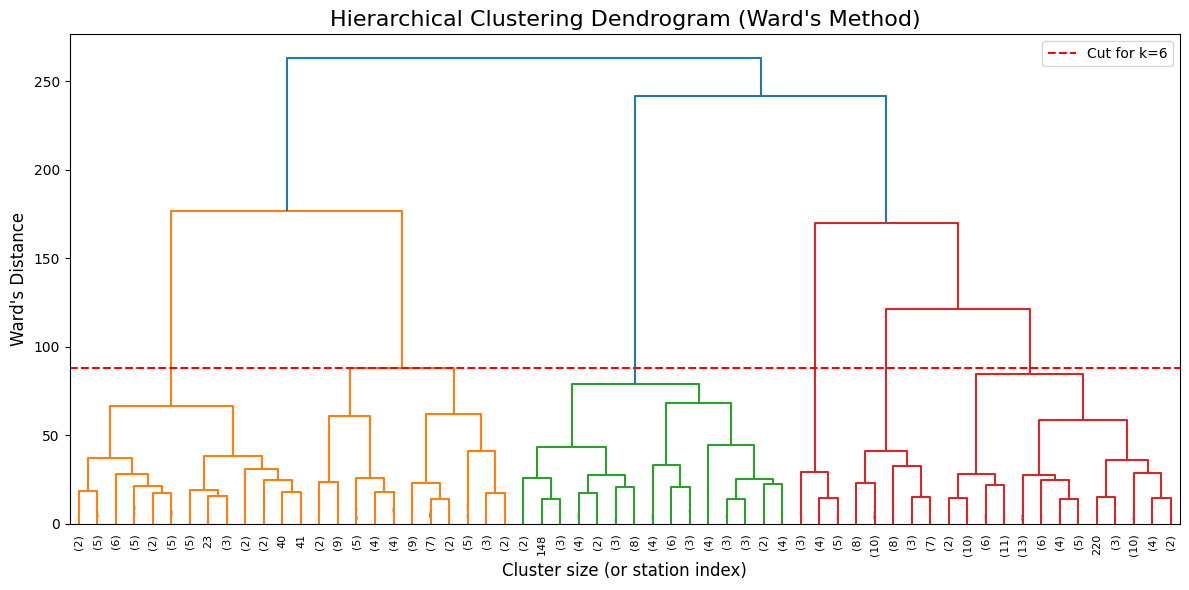

Plotting map...


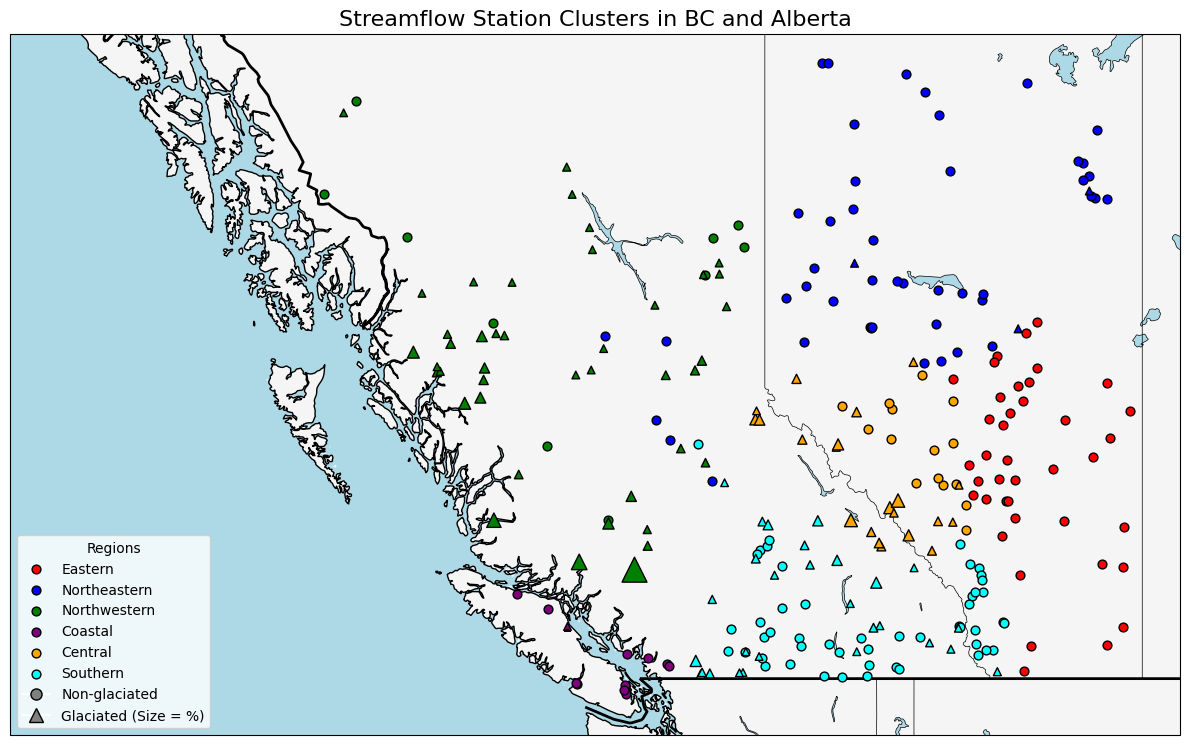

Plotting hydrographs...


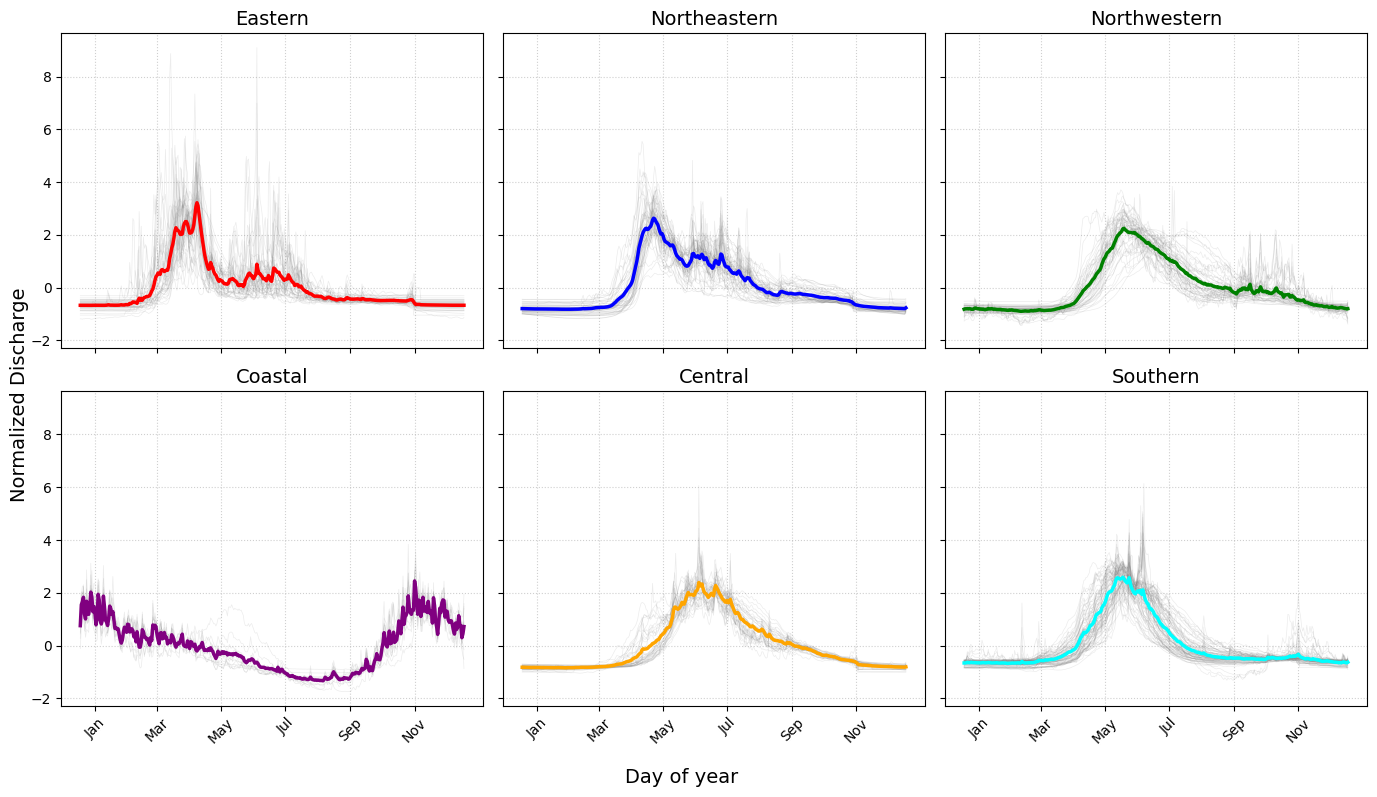

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines
from src.config import PROCESSED_DATA_DIR, RAW_DATA_DIR

# =========================================================
# 1. Load Data
# =========================================================
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_meta = pd.read_csv(RAW_DATA_DIR / "station_metadata.csv", index_col=0) 
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0) 

df_obs.index = pd.to_datetime(df_obs.index)

# =========================================================
# 2. Imputation
# =========================================================
print("Starting imputation...")
df_obs = df_obs.interpolate(method='linear', limit=7)

doy_mean = df_obs.groupby(df_obs.index.dayofyear).transform('mean')
df_obs = df_obs.fillna(doy_mean)

annual_min = df_obs.groupby(df_obs.index.year).transform('min')
df_obs = df_obs.fillna(annual_min)
df_obs = df_obs.fillna(df_obs.min())

# =========================================================
# 3. Average Hydrograph & Normalization (Rolling Avg Removed)
# =========================================================
print("Computing hydrographs and clustering...")
# Calculate the daily average across all years for each station
avg_hydrograph = df_obs.groupby(df_obs.index.dayofyear).mean()

# Normalize to mean=0, std=1
avg_hydrograph_norm = (avg_hydrograph - avg_hydrograph.mean()) / avg_hydrograph.std()

# =========================================================
# 4. Ward's Hierarchical Clustering
# =========================================================
X_hydro = avg_hydrograph_norm.T
X_merged = X_hydro.join(df_meta[['Latitude', 'Longitude']], how='inner')

hydro_features = X_merged.drop(columns=['Latitude', 'Longitude']).values

# Normalize Spatial Features
lat_norm = (X_merged['Latitude'] - X_merged['Latitude'].mean()) / X_merged['Latitude'].std()
lon_norm = (X_merged['Longitude'] - X_merged['Longitude'].mean()) / X_merged['Longitude'].std()

lat_features = np.tile(lat_norm.values, (182, 1)).T
lon_features = np.tile(lon_norm.values, (182, 1)).T

X_cluster_input = np.hstack((hydro_features, lat_features, lon_features))

# Generate the linkage matrix using Ward's method
Z = linkage(X_cluster_input, method='ward')

# =========================================================
# 5. Plot Dendrogram
# =========================================================
print("Plotting dendrogram...")
fig_dendro = plt.figure(figsize=(12, 6))
plt.title("Hierarchical Clustering Dendrogram (Ward's Method)", fontsize=16)
dendrogram(
    Z,
    truncate_mode='lastp',  # Show only the last p merged clusters if there are too many stations
    p=60,                   # Adjust this number to show more/less branches
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_contracted=True
)
plt.xlabel("Cluster size (or station index)", fontsize=12)
plt.ylabel("Ward's Distance", fontsize=12)
# Draw a horizontal line to show where we cut the tree for k=6
cut_distance = Z[-(7-1), 2]  # approximate threshold for 6 clusters
plt.axhline(y=cut_distance, color='r', linestyle='--', label=f'Cut for k=6')
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 6. Extract Clusters & Prep for Mapping
# =========================================================
# Extract exactly 6 clusters. fcluster returns 1-indexed labels, so subtract 1.
cluster_labels = fcluster(Z, t=6, criterion='maxclust') - 1

df_clusters = pd.DataFrame({'Cluster': cluster_labels}, index=X_merged.index)
df_plot = df_clusters.join(df_meta[['Latitude', 'Longitude']], how='inner')
df_plot = df_plot.join(df_attr[['glacier_pct']], how='left')
df_plot['glacier_pct'] = df_plot['glacier_pct'].fillna(0)

cluster_names = {
    0: "Eastern",
    1: "Northeastern",
    2: "Northwestern",
    3: "Coastal",
    4: "Central",
    5: "Southern"
}

colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan']

# =========================================================
# 7. Plotting Map
# =========================================================
print("Plotting map...")
fig_map = plt.figure(figsize=(12, 10))
ax_map = plt.axes(projection=ccrs.Mercator())
ax_map.set_extent([-140, -109, 48, 59], crs=ccrs.PlateCarree())

res = '10m' 
ax_map.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax_map.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightblue', zorder=0)
ax_map.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=1)
ax_map.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightblue', edgecolor='black', linewidth=0.5, zorder=2)

provinces = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale=res, facecolor='none'
)
ax_map.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
ax_map.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=2.0, zorder=3)

for cluster_id in range(6):
    cluster_data = df_plot[df_plot['Cluster'] == cluster_id]
    non_glac = cluster_data[cluster_data['glacier_pct'] == 0]
    glac = cluster_data[cluster_data['glacier_pct'] > 0]
    
    label_name = cluster_names[cluster_id]
    
    if not non_glac.empty:
        ax_map.scatter(
            non_glac['Longitude'], non_glac['Latitude'], 
            transform=ccrs.PlateCarree(),
            color=colors[cluster_id], 
            s=40, marker='o', edgecolors='k', zorder=5,
            label=label_name
        )
        
    if not glac.empty:
        triangle_sizes = (glac['glacier_pct'] * 5) + 30 
        ax_map.scatter(
            glac['Longitude'], glac['Latitude'], 
            transform=ccrs.PlateCarree(),
            color=colors[cluster_id], 
            s=triangle_sizes, marker='^', edgecolors='k', zorder=5
        )

handles, labels = ax_map.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
circle_marker = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='gray', markersize=8, markeredgecolor='k', label='Non-glaciated')
triangle_marker = mlines.Line2D([], [], color='white', marker='^', markerfacecolor='gray', markersize=10, markeredgecolor='k', label='Glaciated (Size = %)')
legend_handles = list(unique_labels.values()) + [circle_marker, triangle_marker]

plt.title('Streamflow Station Clusters in BC and Alberta', fontsize=16)
plt.legend(handles=legend_handles, loc='lower left', title="Regions")
plt.tight_layout()
plt.show()

# =========================================================
# 8. Hydrograph Grids 
# =========================================================
print("Plotting hydrographs...")
fig_hydro, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

month_ticks = [15, 74, 135, 196, 258, 319]
month_labels = ['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov']

for cluster_id in range(6):
    ax = axes[cluster_id]
    station_names = df_clusters[df_clusters['Cluster'] == cluster_id].index
    cluster_hydro_data = avg_hydrograph_norm[station_names]
    
    ax.plot(cluster_hydro_data.index, cluster_hydro_data.values, color='gray', alpha=0.15, linewidth=0.5)
    
    cluster_mean = cluster_hydro_data.mean(axis=1)
    ax.plot(cluster_mean.index, cluster_mean.values, color=colors[cluster_id], linewidth=2.5)
    
    ax.set_title(cluster_names[cluster_id], fontsize=14)
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels, rotation=45)
    ax.grid(True, linestyle=':', alpha=0.6)

fig_hydro.supxlabel('Day of year', fontsize=14)
fig_hydro.supylabel('Normalized Discharge', fontsize=14)
plt.tight_layout()
plt.show()

Plotting NSE map...


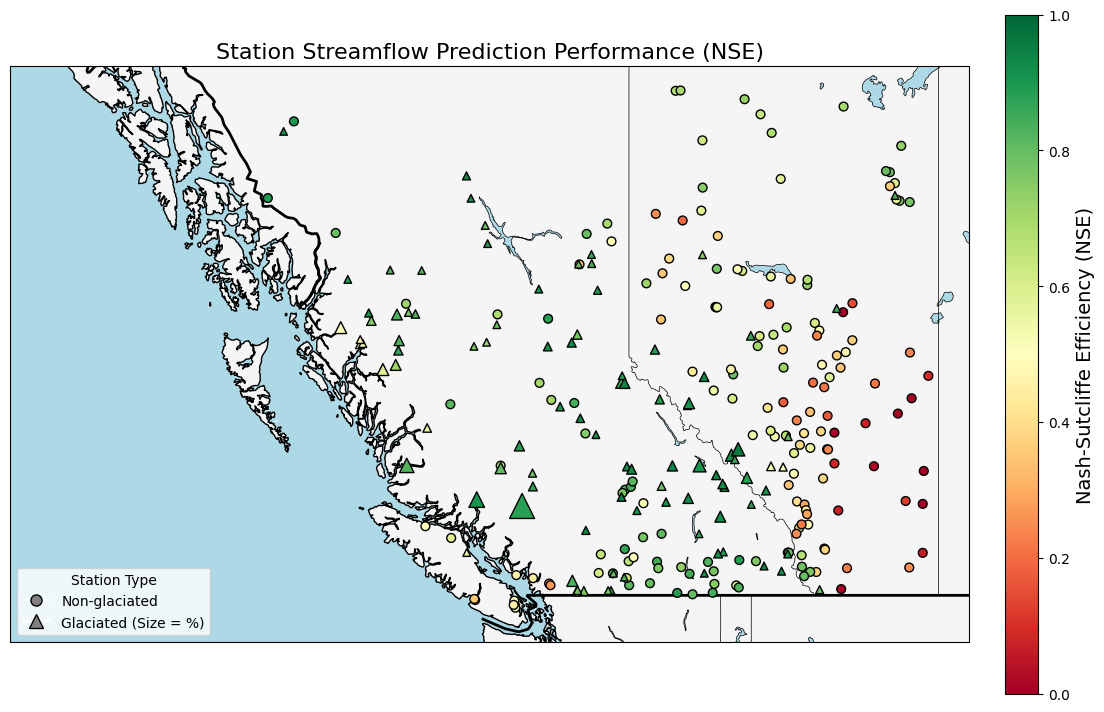

Plotting NSE boxplots...


C:\Users\tbwil\AppData\Local\Temp\ipykernel_25456\1492313550.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


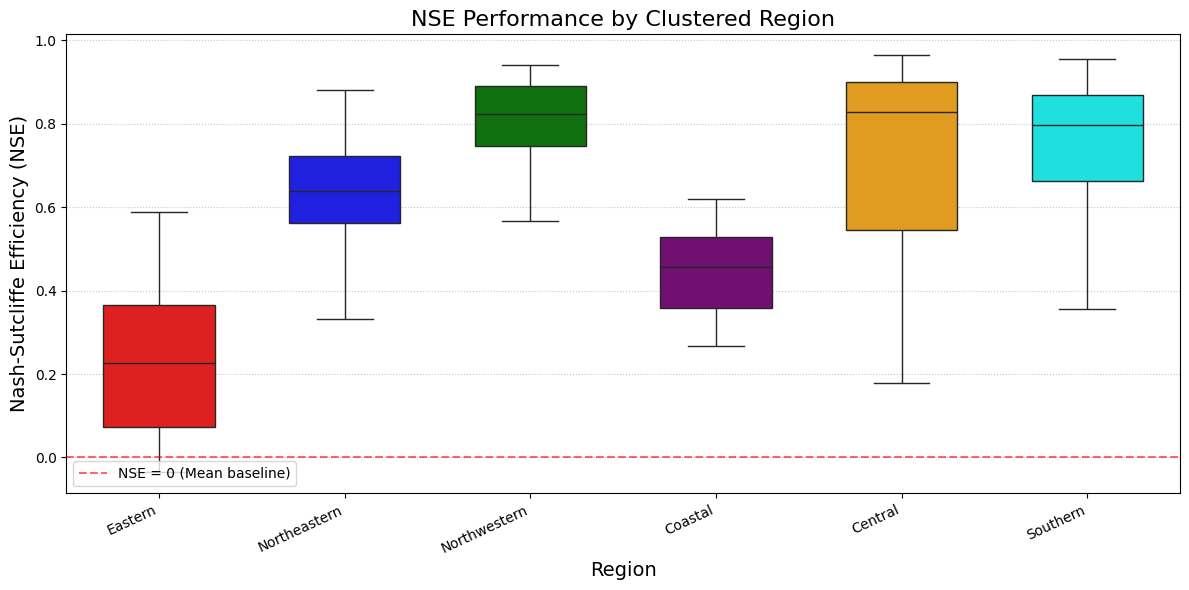

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines
import seaborn as sns
from src.config import OUTPUT_DATA_DIR

# =========================================================
# 1. Load NSE Data and Merge
# =========================================================
# Load the NSE results computed previously
df_nse = pd.read_csv(OUTPUT_DATA_DIR / 'station_performance_metrics.csv', index_col=0)

# Merge the NSE data with our existing plotting dataframe
# df_plot contains Latitude, Longitude, Cluster, and glacier_pct
df_merged = df_plot.join(df_nse, how='inner')

# Add the descriptive cluster names for the box plot
df_merged['Cluster_Name'] = df_merged['Cluster'].map(cluster_names)

# Define color scale limits for the map (capping min NSE for better color contrast)
# vmin = max(-1.0, df_merged['NSE'].quantile(0.05)) # Cap visual min at -1.0 or 5th percentile
vmin = 0
vmax = 1.0 # Perfect NSE

# =========================================================
# 2. NSE Spatial Map
# =========================================================
print("Plotting NSE map...")
fig_map = plt.figure(figsize=(12, 10))
ax_map = plt.axes(projection=ccrs.Mercator())
ax_map.set_extent([-140, -109, 48, 59], crs=ccrs.PlateCarree())

# --- Map Features ---
res = '10m' 
ax_map.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax_map.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightblue', zorder=0)
ax_map.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=1)
ax_map.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightblue', edgecolor='black', linewidth=0.5, zorder=2)

provinces = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale=res, facecolor='none'
)
ax_map.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
ax_map.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=2.0, zorder=3)

# --- Plotting Stations ---
non_glac = df_merged[df_merged['glacier_pct'] == 0]
glac = df_merged[df_merged['glacier_pct'] > 0]

# Using 'viridis' colormap where yellow is high NSE (good) and dark purple is low (bad)
# cmap = 'viridis'
cmap = 'RdYlGn'

if not non_glac.empty:
    sc_circles = ax_map.scatter(
        non_glac['Longitude'], non_glac['Latitude'], 
        transform=ccrs.PlateCarree(),
        c=non_glac['NSE'], cmap=cmap, vmin=vmin, vmax=vmax,
        s=40, marker='o', edgecolors='k', zorder=5
    )
    
if not glac.empty:
    triangle_sizes = (glac['glacier_pct'] * 5) + 30 
    sc_triangles = ax_map.scatter(
        glac['Longitude'], glac['Latitude'], 
        transform=ccrs.PlateCarree(),
        c=glac['NSE'], cmap=cmap, vmin=vmin, vmax=vmax,
        s=triangle_sizes, marker='^', edgecolors='k', zorder=5
    )

# --- Colorbar and Legend ---
# We use one of the scatter objects (sc_circles or sc_triangles) to generate the colorbar
mappable = sc_circles if not non_glac.empty else sc_triangles
cbar = plt.colorbar(mappable, ax=ax_map, orientation='vertical', shrink=0.7, pad=0.03)
cbar.set_label('Nash-Sutcliffe Efficiency (NSE)', fontsize=14)

# Keep the shape legend
circle_marker = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='gray', markersize=8, markeredgecolor='k', label='Non-glaciated')
triangle_marker = mlines.Line2D([], [], color='white', marker='^', markerfacecolor='gray', markersize=10, markeredgecolor='k', label='Glaciated (Size = %)')
plt.legend(handles=[circle_marker, triangle_marker], loc='lower left', title="Station Type")

plt.title('Station Streamflow Prediction Performance (NSE)', fontsize=16)
plt.tight_layout()
plt.show()

# =========================================================
# 3. NSE Box Plot by Cluster
# =========================================================
print("Plotting NSE boxplots...")
fig_box = plt.figure(figsize=(12, 6))

# Sort the dataframe so the clusters appear in order 0-5
df_merged_sorted = df_merged.sort_values('Cluster')

# Use seaborn to create a clean boxplot, matching the cluster colors from earlier
sns.boxplot(
    data=df_merged_sorted, 
    x='Cluster_Name', 
    y='NSE', 
    palette=colors,
    width=0.6,
    fliersize=4, # size of outlier points
    showfliers=False
)

# Add a dashed red reference line for an NSE of 0
plt.axhline(y=0, color='r', linestyle='--', alpha=0.6, label='NSE = 0 (Mean baseline)')

plt.title('NSE Performance by Clustered Region', fontsize=16)
plt.xlabel('Region', fontsize=14)
plt.ylabel('Nash-Sutcliffe Efficiency (NSE)', fontsize=14)
plt.xticks(rotation=25, ha='right')
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Analyzing 95 glaciated stations...


c:\Users\tbwil\Documents\School\MSc Geophysics\Thesis Project\.venv\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


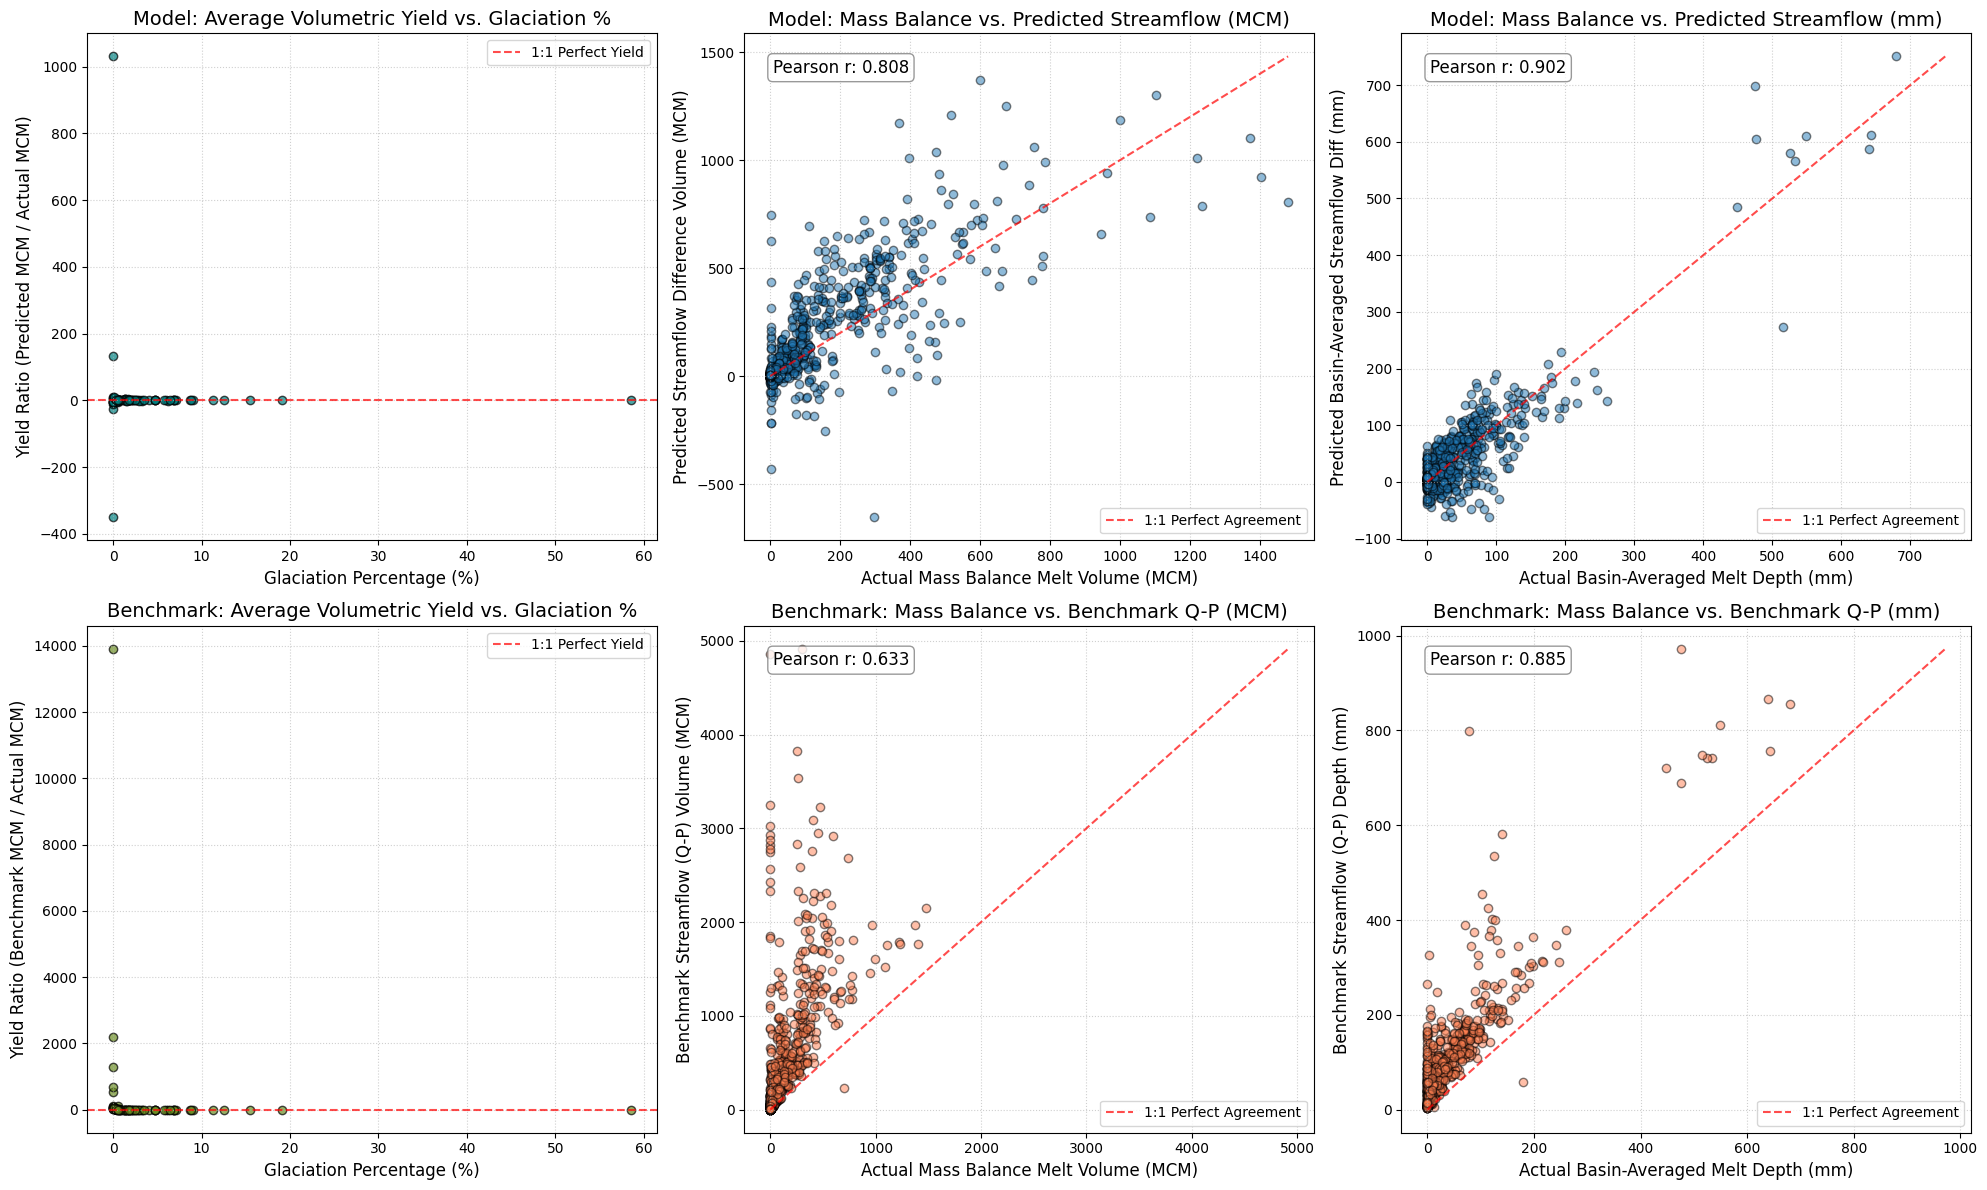

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from src.config import PROCESSED_DATA_DIR, CLIMATE_OUTPUT_DIR, OUTPUT_DATA_DIR

# =========================================================
# 1. Load Data
# =========================================================
# Load predictions
df_pred = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
df_pred_no_glac = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions_no_glacier.csv", index_col=0, parse_dates=True)

# Load mass balance and attributes
df_mb = - pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)

# Load Ground Truth Streamflow and Precipitation for Benchmark
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_prcp = pd.read_csv(CLIMATE_OUTPUT_DIR / "daily_precipitation.csv", index_col=0, parse_dates=True)

# =========================================================
# 2. Filter and Isolate August Data for Glaciated Stations
# =========================================================
# Identify glaciated stations common to all datasets (>5% glaciation)
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index
common_stations = glaciated_stations.intersection(df_pred.columns) \
                                    .intersection(df_mb.columns) \
                                    .intersection(df_obs.columns) \
                                    .intersection(df_prcp.columns)

print(f"Analyzing {len(common_stations)} glaciated stations...")

# Filter datasets
df_pred = df_pred[common_stations]
df_pred_no_glac = df_pred_no_glac[common_stations]
df_mb = df_mb[common_stations]
df_obs = df_obs[common_stations]
df_prcp = df_prcp[common_stations]

# Convert ground truth streamflow and precipitation to mm/day
for station in common_stations:
    area_km2 = df_attr.loc[station, 'basin_area_km2'] 
    df_obs[station] = df_obs[station] * (86.4 / area_km2)
    df_prcp[station] = df_prcp[station] / area_km2

# --- Calculate August Sums ---
# Model Difference (mm/month)
df_diff = df_pred - df_pred_no_glac
df_diff_aug_yearly = df_diff[df_diff.index.month == 8].groupby(df_diff[df_diff.index.month == 8].index.year).sum()

# Benchmark Q-P (mm/month)
df_obs_aug_yearly = df_obs[df_obs.index.month == 8].groupby(df_obs[df_obs.index.month == 8].index.year).sum()
df_prcp_aug_yearly = df_prcp[df_prcp.index.month == 8].groupby(df_prcp[df_prcp.index.month == 8].index.year).sum()
df_bench_aug_yearly = df_obs_aug_yearly - df_prcp_aug_yearly

# Actual Mass Balance (Already in MCM)
df_mb_aug_yearly = df_mb[df_mb.index.month == 8].groupby(df_mb[df_mb.index.month == 8].index.year).sum()

# Align years across all datasets
common_years = df_diff_aug_yearly.index.intersection(df_mb_aug_yearly.index).intersection(df_bench_aug_yearly.index)
df_diff_aug_yearly = df_diff_aug_yearly.loc[common_years]
df_mb_aug_yearly = df_mb_aug_yearly.loc[common_years]
df_bench_aug_yearly = df_bench_aug_yearly.loc[common_years]

# =========================================================
# 3. Calculate Volumes (MCM) and Depths (mm)
# =========================================================
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']
glac_pct = df_attr.loc[common_stations, 'glacier_pct']

# --- Volume Calculation (MCM) ---
actual_mcm = df_mb_aug_yearly
pred_mcm = df_diff_aug_yearly * basin_areas * 0.001
bench_mcm = df_bench_aug_yearly * basin_areas * 0.001

# --- Depth Calculation (Basin-Averaged mm) ---
pred_mm = df_diff_aug_yearly
bench_mm = df_bench_aug_yearly
actual_mm = (actual_mcm * 1000).div(basin_areas, axis=1)

# =========================================================
# 4. Calculate Glacier Yield Ratios
# =========================================================
# Ratio: Estimated MCM / Actual MCM
ratio_pred = pred_mcm / actual_mcm
ratio_bench = bench_mcm / actual_mcm

avg_ratio_pred = ratio_pred.mean().replace([np.inf, -np.inf], np.nan)
avg_ratio_bench = ratio_bench.mean().replace([np.inf, -np.inf], np.nan)

# =========================================================
# 5. Prepare Data for Scatter Plots (Flatten & Clean)
# =========================================================
def get_clean_flat_data(actual_df, est_df):
    actual_flat = actual_df.values.flatten()
    est_flat = est_df.values.flatten()
    valid_mask = ~(np.isnan(actual_flat) | np.isnan(est_flat))
    x_clean = actual_flat[valid_mask]
    y_clean = est_flat[valid_mask]
    corr, _ = stats.pearsonr(x_clean, y_clean)
    return x_clean, y_clean, corr

# Flatten MCM Data
x_actual_mcm_pred, y_pred_mcm, corr_pred_mcm = get_clean_flat_data(actual_mcm, pred_mcm)
x_actual_mcm_bench, y_bench_mcm, corr_bench_mcm = get_clean_flat_data(actual_mcm, bench_mcm)

# Flatten MM Data
x_actual_mm_pred, y_pred_mm, corr_pred_mm = get_clean_flat_data(actual_mm, pred_mm)
x_actual_mm_bench, y_bench_mm, corr_bench_mm = get_clean_flat_data(actual_mm, bench_mm)

# =========================================================
# 6. Plotting
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')

def plot_scatter(ax, x, y, title, xlabel, ylabel, color, corr=None, add_1to1=True):
    ax.scatter(x, y, color=color, alpha=0.5, edgecolor='k')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    if corr is not None:
        ax.text(0.05, 0.95, f'Pearson r: {corr:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)
        
    if add_1to1:
        max_val = max(x.max(), y.max())
        min_val = min(min(x), min(y), 0) # Handle negative values if any exist
        ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.7, label='1:1 Perfect Agreement')
        ax.legend(loc='lower right')
        
    ax.grid(True, linestyle=':', alpha=0.6)

# ---------------------------------------------------------
# ROW 1: MODEL PREDICTIONS
# ---------------------------------------------------------
# Panel 1: Yield vs Glaciation
axes[0,0].scatter(glac_pct, avg_ratio_pred, color='teal', alpha=0.7, edgecolor='k')
axes[0,0].set_title('Model: Average Volumetric Yield vs. Glaciation %', fontsize=14)
axes[0,0].set_xlabel('Glaciation Percentage (%)', fontsize=12)
axes[0,0].set_ylabel('Yield Ratio (Predicted MCM / Actual MCM)', fontsize=12)
axes[0,0].axhline(1, color='red', linestyle='--', alpha=0.7, label='1:1 Perfect Yield')
axes[0,0].legend()
axes[0,0].grid(True, linestyle=':', alpha=0.6)

# Panel 2: MCM Correlation
plot_scatter(axes[0,1], x_actual_mcm_pred, y_pred_mcm, 
             'Model: Mass Balance vs. Predicted Streamflow (MCM)',
             'Actual Mass Balance Melt Volume (MCM)', 'Predicted Streamflow Difference Volume (MCM)', 
             'tab:blue', corr_pred_mcm)

# Panel 3: MM Correlation
plot_scatter(axes[0,2], x_actual_mm_pred, y_pred_mm, 
             'Model: Mass Balance vs. Predicted Streamflow (mm)',
             'Actual Basin-Averaged Melt Depth (mm)', 'Predicted Basin-Averaged Streamflow Diff (mm)', 
             'tab:blue', corr_pred_mm)

# ---------------------------------------------------------
# ROW 2: BENCHMARK (Q-P)
# ---------------------------------------------------------
# Panel 1: Yield vs Glaciation
axes[1,0].scatter(glac_pct, avg_ratio_bench, color='olivedrab', alpha=0.7, edgecolor='k')
axes[1,0].set_title('Benchmark: Average Volumetric Yield vs. Glaciation %', fontsize=14)
axes[1,0].set_xlabel('Glaciation Percentage (%)', fontsize=12)
axes[1,0].set_ylabel('Yield Ratio (Benchmark MCM / Actual MCM)', fontsize=12)
axes[1,0].axhline(1, color='red', linestyle='--', alpha=0.7, label='1:1 Perfect Yield')
axes[1,0].legend()
axes[1,0].grid(True, linestyle=':', alpha=0.6)

# Panel 2: MCM Correlation
plot_scatter(axes[1,1], x_actual_mcm_bench, y_bench_mcm, 
             'Benchmark: Mass Balance vs. Benchmark Q-P (MCM)',
             'Actual Mass Balance Melt Volume (MCM)', 'Benchmark Streamflow (Q-P) Volume (MCM)', 
             'coral', corr_bench_mcm)

# Panel 3: MM Correlation
plot_scatter(axes[1,2], x_actual_mm_bench, y_bench_mm, 
             'Benchmark: Mass Balance vs. Benchmark Q-P (mm)',
             'Actual Basin-Averaged Melt Depth (mm)', 'Benchmark Streamflow (Q-P) Depth (mm)', 
             'coral', corr_bench_mm)

plt.tight_layout()
plt.show()

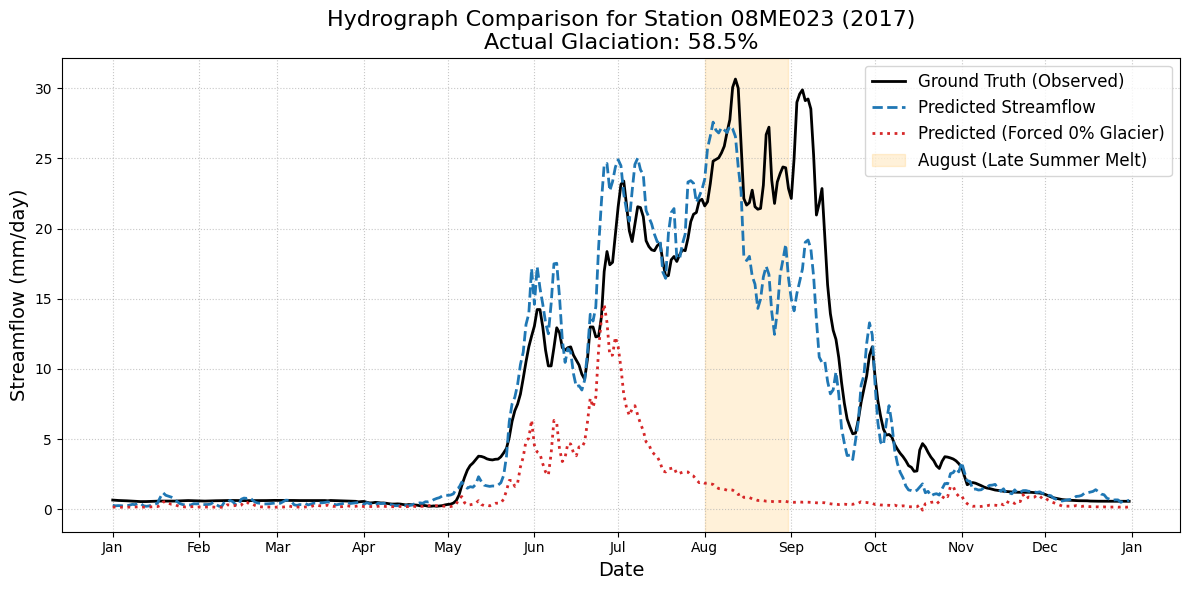

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

# =========================================================
# 1. Define Target Station and Year
# =========================================================
# Change these to explore different stations and years
# TARGET_STATION = '05BA001' # Replace with your actual station ID string
TARGET_STATION = '08ME023'
TARGET_YEAR = 2017         # Replace with a year in your test set (e.g., 2013-2022)

# =========================================================
# 2. Load Data
# =========================================================
# Ground truth (m³/s)
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
# Predictions (mm/day)
df_pred = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
# Predictions with 0% glaciation (mm/day)
df_pred_no_glac = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions_no_glacier.csv", index_col=0, parse_dates=True)

# Station Attributes
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)

# =========================================================
# 3. Data Extraction and Conversion
# =========================================================
# Check if station exists in the attributes
if TARGET_STATION not in df_attr.index:
    raise ValueError(f"Station {TARGET_STATION} not found in static_attributes.csv")

# Extract the data for the target station
try:
    obs_station = df_obs[TARGET_STATION]
    pred_station = df_pred[TARGET_STATION]
    pred_no_glac_station = df_pred_no_glac[TARGET_STATION]
except KeyError:
    raise KeyError(f"Station {TARGET_STATION} is missing from one of the timeseries files.")

# Convert observed flow from m³/s to mm/day
area_km2 = df_attr.loc[TARGET_STATION, 'basin_area_km2']
glacier_pct = df_attr.loc[TARGET_STATION, 'glacier_pct']

# Conversion: 1 m³/s = 86.4 / Area (km²) mm/day
obs_station_mm = obs_station * (86.4 / area_km2)

# Filter for the target year
obs_year = obs_station_mm[obs_station_mm.index.year == TARGET_YEAR]
pred_year = pred_station[pred_station.index.year == TARGET_YEAR]
pred_no_glac_year = pred_no_glac_station[pred_no_glac_station.index.year == TARGET_YEAR]

if pred_year.empty:
    print(f"Warning: No prediction data found for year {TARGET_YEAR}.")

# =========================================================
# 4. Plotting
# =========================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the three lines with distinct styles
ax.plot(obs_year.index, obs_year.values, 
        color='black', linewidth=2, label='Ground Truth (Observed)')

ax.plot(pred_year.index, pred_year.values, 
        color='tab:blue', linewidth=2, linestyle='--', label='Predicted Streamflow')

ax.plot(pred_no_glac_year.index, pred_no_glac_year.values, 
        color='tab:red', linewidth=2, linestyle=':', label='Predicted (Forced 0% Glacier)')

# Formatting the plot
ax.set_title(f'Hydrograph Comparison for Station {TARGET_STATION} ({TARGET_YEAR})\nActual Glaciation: {glacier_pct:.1f}%', fontsize=16)
ax.set_ylabel('Streamflow (mm/day)', fontsize=14)
ax.set_xlabel('Date', fontsize=14)

# Format the x-axis to show months clearly
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(fontsize=12, loc='upper left')

# Highlight the late summer melt season (typically August)
august_start = pd.to_datetime(f'{TARGET_YEAR}-08-01')
august_end = pd.to_datetime(f'{TARGET_YEAR}-08-31')
ax.axvspan(august_start, august_end, color='orange', alpha=0.15, label='August (Late Summer Melt)')

# Update legend to include the highlighted region
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

Define a benchmark: August streamflow minus August precip. is approximately the glacier melt

High estimated melt with low mass balance change: implies that there is a lot more streamflow than rain. This suggests either glacier, late season snowmelt, or baseflow. Given glacier melt is low, I would assume that the glacier is being sheltered from melt which implies a significant amount of late season snowmelt.

Plotting data for 95 glaciated stations...
Correlation: 0.997 (p-value: 1.289e-105)


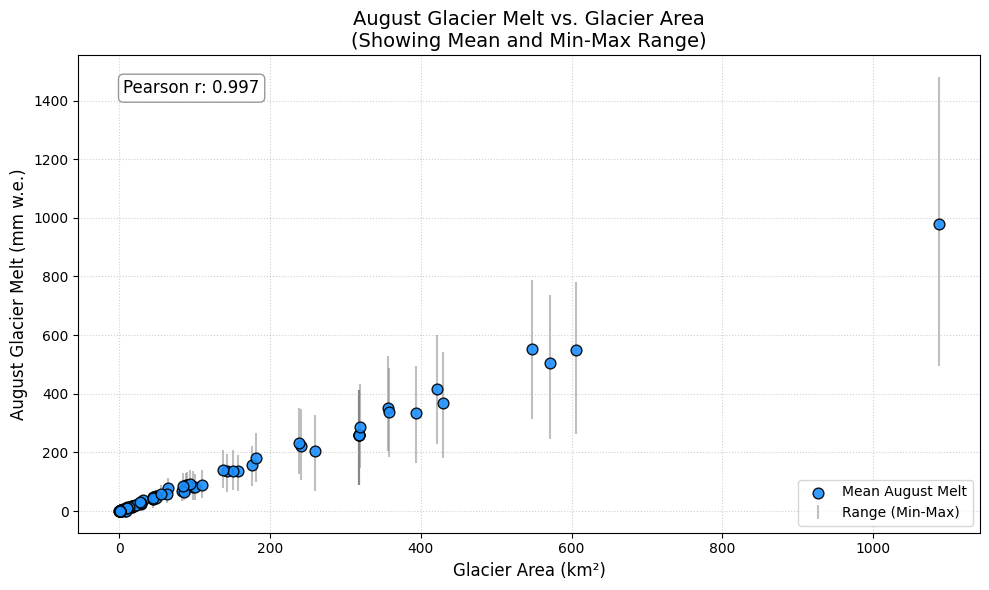

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from src.config import PROCESSED_DATA_DIR

# =========================================================
# 1. Load Data
# =========================================================
# Load attributes to get glacier area
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)

# Load mass balance and negate it so that mass loss (melt) is positive
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)

# =========================================================
# 2. Extract and Process August Melt
# =========================================================
# Filter mass balance data for August only
df_mb_aug = df_mb[df_mb.index.month == 8]

# Group by year to get the total August melt per year
df_mb_aug_yearly = df_mb_aug.groupby(df_mb_aug.index.year).sum()

# Calculate the mean, min, and max across all years
mean_aug_melt = df_mb_aug_yearly.mean()
min_aug_melt = df_mb_aug_yearly.min()
max_aug_melt = df_mb_aug_yearly.max()

# Identify valid glaciated stations common to both datasets
glaciated_stations = df_attr[df_attr['glacier_area_km2'] > 0].index
common_stations = glaciated_stations.intersection(mean_aug_melt.index)

print(f"Plotting data for {len(common_stations)} glaciated stations...")

# Extract aligned data
glacier_area = df_attr.loc[common_stations, 'glacier_area_km2']
aug_melt_mean = mean_aug_melt.loc[common_stations]
aug_melt_min = min_aug_melt.loc[common_stations]
aug_melt_max = max_aug_melt.loc[common_stations]

# Drop any NaNs to ensure clean plotting
valid_mask = ~(np.isnan(glacier_area) | np.isnan(aug_melt_mean))
clean_area = glacier_area[valid_mask]
clean_mean = aug_melt_mean[valid_mask]
clean_min = aug_melt_min[valid_mask]
clean_max = aug_melt_max[valid_mask]

# Calculate the error bounds relative to the mean for the errorbar function
yerr_lower = clean_mean - clean_min
yerr_upper = clean_max - clean_mean
yerr = [yerr_lower, yerr_upper]

# Calculate Pearson correlation (using the means)
corr, p_value = stats.pearsonr(clean_area, clean_mean)
print(f"Correlation: {corr:.3f} (p-value: {p_value:.3e})")

# =========================================================
# 3. Plotting
# =========================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the ranges (min to max) as error bars behind the scatter points
ax.errorbar(clean_area, clean_mean, yerr=yerr, fmt='none', ecolor='gray', 
            alpha=0.5, zorder=1, label='Range (Min-Max)')

# Plot the means as scatter points on top
ax.scatter(clean_area, clean_mean, color='dodgerblue', alpha=0.9, 
           edgecolor='k', s=60, zorder=2, label='Mean August Melt')

ax.set_title('August Glacier Melt vs. Glacier Area\n(Showing Mean and Min-Max Range)', fontsize=14)
ax.set_xlabel('Glacier Area (km²)', fontsize=12)
ax.set_ylabel('August Glacier Melt (mm w.e.)', fontsize=12)

# Add correlation text to the plot
textstr = f'Pearson r: {corr:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

Calculating correlations for 95 glaciated stations...
Plotting maps...


C:\Users\tbwil\AppData\Local\Temp\ipykernel_25456\2771593802.py:61: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = stats.pearsonr(target_series[valid_mask], stat_series[valid_mask])


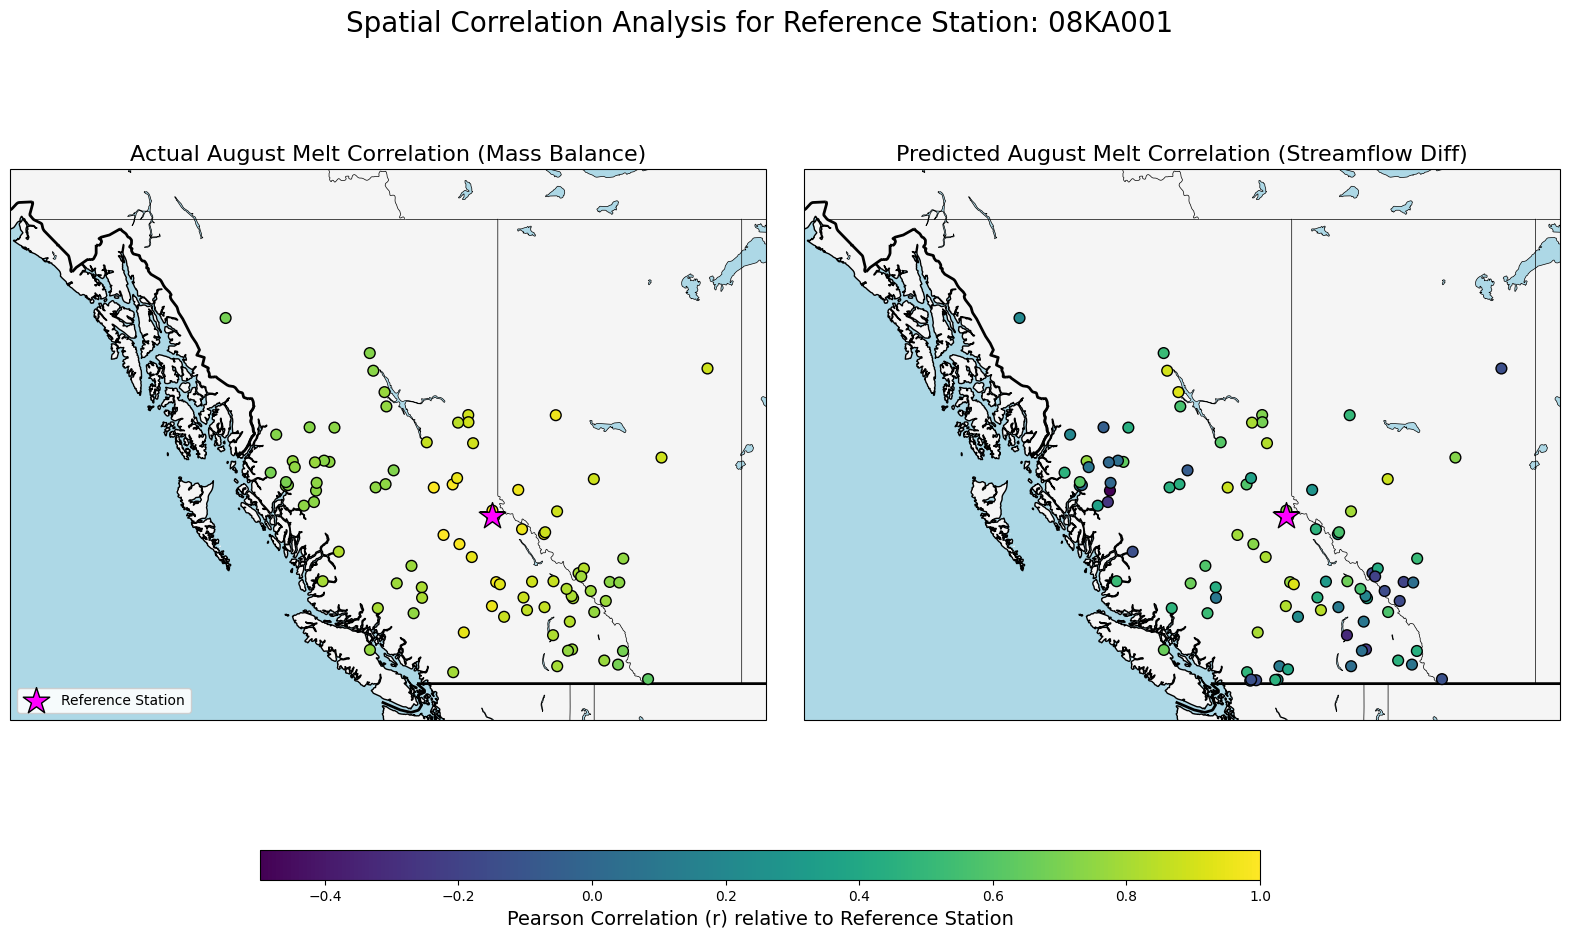

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, RAW_DATA_DIR

# =========================================================
# 1. Define Target Reference Station
# =========================================================
TARGET_STATION = '08KA001' 

# =========================================================
# 2. Load Data
# =========================================================
# Load mass balance (actual melt)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)

# Load predictions (predicted melt difference)
df_pred = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
df_pred_no_glac = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions_no_glacier.csv", index_col=0, parse_dates=True)

# Load attributes and metadata
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_meta = pd.read_csv(RAW_DATA_DIR / "station_metadata.csv", index_col=0)

# =========================================================
# 3. Extract August Timeseries
# =========================================================
# --- Actual Melt (Mass Balance) ---
df_mb_aug = df_mb[df_mb.index.month == 8]
df_mb_aug_yearly = df_mb_aug.groupby(df_mb_aug.index.year).sum()

# --- Predicted Melt (Streamflow Difference) ---
df_diff = df_pred - df_pred_no_glac
df_diff_aug = df_diff[df_diff.index.month == 8]
df_diff_aug_yearly = df_diff_aug.groupby(df_diff_aug.index.year).sum()

# Identify common glaciated stations across ALL datasets
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index
common_stations = glaciated_stations.intersection(df_mb_aug_yearly.columns) \
                                    .intersection(df_diff_aug_yearly.columns) \
                                    .intersection(df_meta.index)

print(f"Calculating correlations for {len(common_stations)} glaciated stations...")

if TARGET_STATION not in common_stations:
    raise ValueError(f"Target station {TARGET_STATION} not found in the valid station list.")

# =========================================================
# 4. Calculate Correlations
# =========================================================
def get_correlations(df_yearly, target_stat, stations):
    target_series = df_yearly[target_stat]
    corrs = {}
    for stat in stations:
        stat_series = df_yearly[stat]
        valid_mask = ~(np.isnan(target_series) | np.isnan(stat_series))
        if valid_mask.sum() > 3:
            corr, _ = stats.pearsonr(target_series[valid_mask], stat_series[valid_mask])
            corrs[stat] = corr
        else:
            corrs[stat] = np.nan
    return pd.Series(corrs, name='Correlation').to_frame()

# Calculate both sets of correlations
df_corr_mb = get_correlations(df_mb_aug_yearly, TARGET_STATION, common_stations)
df_corr_pred = get_correlations(df_diff_aug_yearly, TARGET_STATION, common_stations)

# Merge with coordinates
df_plot_mb = df_corr_mb.join(df_meta[['Latitude', 'Longitude']], how='inner').dropna(subset=['Correlation'])
df_plot_pred = df_corr_pred.join(df_meta[['Latitude', 'Longitude']], how='inner').dropna(subset=['Correlation'])

# =========================================================
# 5. Plotting the Side-by-Side Maps
# =========================================================
print("Plotting maps...")

# Determine shared color scale limits
vmin = min(df_plot_mb['Correlation'].min(), df_plot_pred['Correlation'].min())
vmax = max(df_plot_mb['Correlation'].max(), df_plot_pred['Correlation'].max())

fig, axes = plt.subplots(1, 2, figsize=(20, 10), subplot_kw={'projection': ccrs.Mercator()})

titles = [
    f'Actual August Melt Correlation (Mass Balance)',
    f'Predicted August Melt Correlation (Streamflow Diff)'
]
plot_data = [df_plot_mb, df_plot_pred]

for i, ax in enumerate(axes):
    ax.set_extent([-140, -109, 48, 61], crs=ccrs.PlateCarree())

    # --- Map Features ---
    res = '10m' 
    ax.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightblue', edgecolor='black', linewidth=0.5, zorder=2)

    provinces = cfeature.NaturalEarthFeature(
        category='cultural', name='admin_1_states_provinces_lines',
        scale=res, facecolor='none'
    )
    ax.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=2.0, zorder=3)

    # --- Plot Correlation Scatter ---
    sc = ax.scatter(
        plot_data[i]['Longitude'], plot_data[i]['Latitude'], 
        transform=ccrs.PlateCarree(),
        c=plot_data[i]['Correlation'], cmap='viridis', vmin=vmin, vmax=vmax,
        s=60, marker='o', edgecolors='k', zorder=5
    )

    # --- Highlight Target Station ---
    target_lat = plot_data[i].loc[TARGET_STATION, 'Latitude']
    target_lon = plot_data[i].loc[TARGET_STATION, 'Longitude']
    ax.scatter(
        target_lon, target_lat, 
        transform=ccrs.PlateCarree(),
        color='magenta', marker='*', s=400, edgecolors='k', zorder=6,
        label=f'Reference Station'
    )

    ax.set_title(titles[i], fontsize=16)
    if i == 0:
        ax.legend(loc='lower left', framealpha=0.9)

# --- Shared Colorbar ---
# Adjust layout to make room for a single colorbar at the bottom
fig.subplots_adjust(bottom=0.15, wspace=0.05)
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03]) # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Pearson Correlation (r) relative to Reference Station', fontsize=14)

fig.suptitle(f'Spatial Correlation Analysis for Reference Station: {TARGET_STATION}', fontsize=20, y=0.95)

plt.show()

Calculating correlations for 95 glaciated stations (>5% glaciation)...


C:\Users\tbwil\AppData\Local\Temp\ipykernel_25456\4081282870.py:82: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = stats.pearsonr(target_series[valid_mask], stat_series[valid_mask])


Plotting maps...


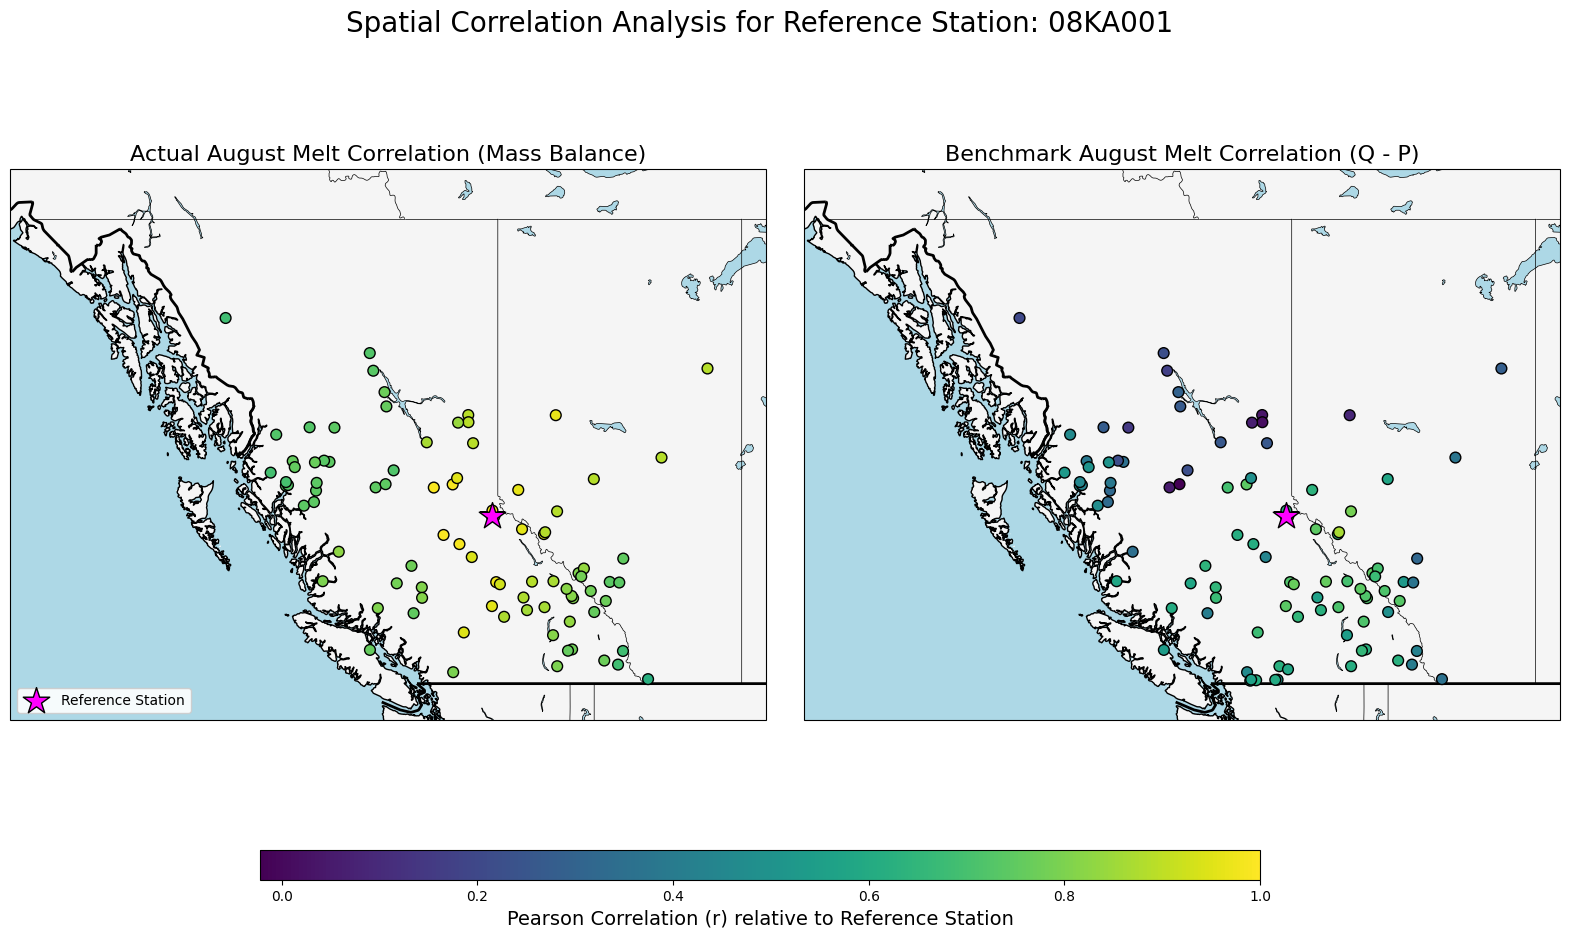

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from src.config import PROCESSED_DATA_DIR, CLIMATE_OUTPUT_DIR, RAW_DATA_DIR

# =========================================================
# 1. Define Target Reference Station
# =========================================================
TARGET_STATION = '08KA001' 

# =========================================================
# 2. Load Data
# =========================================================
# Load Ground Truth Streamflow and Precipitation
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_prcp = pd.read_csv(CLIMATE_OUTPUT_DIR / "daily_precipitation.csv", index_col=0, parse_dates=True)

# Load mass balance (actual melt, negated to be positive)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)

# Load attributes and metadata
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_meta = pd.read_csv(RAW_DATA_DIR / "station_metadata.csv", index_col=0)

# =========================================================
# 3. Filter, Convert, and Extract August Timeseries
# =========================================================
# Identify common glaciated stations (>5% glaciation) across ALL datasets
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index
common_stations = glaciated_stations.intersection(df_obs.columns) \
                                    .intersection(df_prcp.columns) \
                                    .intersection(df_mb.columns) \
                                    .intersection(df_meta.index)

print(f"Calculating correlations for {len(common_stations)} glaciated stations (>5% glaciation)...")

if TARGET_STATION not in common_stations:
    raise ValueError(f"Target station {TARGET_STATION} not found in the valid station list. Check glaciation % or data availability.")

# Filter data for these stations
df_obs = df_obs[common_stations]
df_prcp = df_prcp[common_stations]
df_mb = df_mb[common_stations]

# Convert ground truth streamflow and average precipitation by area
for station in common_stations:
    area_km2 = df_attr.loc[station, 'basin_area_km2'] 
    df_obs[station] = df_obs[station] * (86.4 / area_km2)
    df_prcp[station] = df_prcp[station] / area_km2

# --- Calculate Yearly August Sums ---
# Actual Melt
df_mb_aug = df_mb[df_mb.index.month == 8]
df_mb_aug_yearly = df_mb_aug.groupby(df_mb_aug.index.year).sum()

# Benchmark Melt (Streamflow - Precipitation)
df_obs_aug = df_obs[df_obs.index.month == 8]
df_prcp_aug = df_prcp[df_prcp.index.month == 8]

df_obs_aug_yearly = df_obs_aug.groupby(df_obs_aug.index.year).sum()
df_prcp_aug_yearly = df_prcp_aug.groupby(df_prcp_aug.index.year).sum()
df_benchmark_yearly = df_obs_aug_yearly - df_prcp_aug_yearly

# Align years between the datasets
common_years = df_mb_aug_yearly.index.intersection(df_benchmark_yearly.index)
df_mb_aug_yearly = df_mb_aug_yearly.loc[common_years]
df_benchmark_yearly = df_benchmark_yearly.loc[common_years]

# =========================================================
# 4. Calculate Correlations
# =========================================================
def get_correlations(df_yearly, target_stat, stations):
    target_series = df_yearly[target_stat]
    corrs = {}
    for stat in stations:
        stat_series = df_yearly[stat]
        valid_mask = ~(np.isnan(target_series) | np.isnan(stat_series))
        if valid_mask.sum() > 3:
            corr, _ = stats.pearsonr(target_series[valid_mask], stat_series[valid_mask])
            corrs[stat] = corr
        else:
            corrs[stat] = np.nan
    return pd.Series(corrs, name='Correlation').to_frame()

# Calculate both sets of correlations
df_corr_mb = get_correlations(df_mb_aug_yearly, TARGET_STATION, common_stations)
df_corr_bench = get_correlations(df_benchmark_yearly, TARGET_STATION, common_stations)

# Merge with coordinates
df_plot_mb = df_corr_mb.join(df_meta[['Latitude', 'Longitude']], how='inner').dropna(subset=['Correlation'])
df_plot_bench = df_corr_bench.join(df_meta[['Latitude', 'Longitude']], how='inner').dropna(subset=['Correlation'])

# =========================================================
# 5. Plotting the Side-by-Side Maps
# =========================================================
print("Plotting maps...")

# Determine shared color scale limits
vmin = min(df_plot_mb['Correlation'].min(), df_plot_bench['Correlation'].min())
vmax = max(df_plot_mb['Correlation'].max(), df_plot_bench['Correlation'].max())

fig, axes = plt.subplots(1, 2, figsize=(20, 10), subplot_kw={'projection': ccrs.Mercator()})

titles = [
    f'Actual August Melt Correlation (Mass Balance)',
    f'Benchmark August Melt Correlation (Q - P)'
]
plot_data = [df_plot_mb, df_plot_bench]

for i, ax in enumerate(axes):
    ax.set_extent([-140, -109, 48, 61], crs=ccrs.PlateCarree())

    # --- Map Features ---
    res = '10m' 
    ax.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightblue', edgecolor='black', linewidth=0.5, zorder=2)

    provinces = cfeature.NaturalEarthFeature(
        category='cultural', name='admin_1_states_provinces_lines',
        scale=res, facecolor='none'
    )
    ax.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=2.0, zorder=3)

    # --- Plot Correlation Scatter ---
    sc = ax.scatter(
        plot_data[i]['Longitude'], plot_data[i]['Latitude'], 
        transform=ccrs.PlateCarree(),
        c=plot_data[i]['Correlation'], cmap='viridis', vmin=vmin, vmax=vmax,
        s=60, marker='o', edgecolors='k', zorder=5
    )

    # --- Highlight Target Station ---
    target_lat = plot_data[i].loc[TARGET_STATION, 'Latitude']
    target_lon = plot_data[i].loc[TARGET_STATION, 'Longitude']
    ax.scatter(
        target_lon, target_lat, 
        transform=ccrs.PlateCarree(),
        color='magenta', marker='*', s=400, edgecolors='k', zorder=6,
        label=f'Reference Station'
    )

    ax.set_title(titles[i], fontsize=16)
    if i == 0:
        ax.legend(loc='lower left', framealpha=0.9)

# --- Shared Colorbar ---
fig.subplots_adjust(bottom=0.15, wspace=0.05)
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03]) # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Pearson Correlation (r) relative to Reference Station', fontsize=14)

fig.suptitle(f'Spatial Correlation Analysis for Reference Station: {TARGET_STATION}', fontsize=20, y=0.95)

plt.show()

Analyzing 95 glaciated stations...


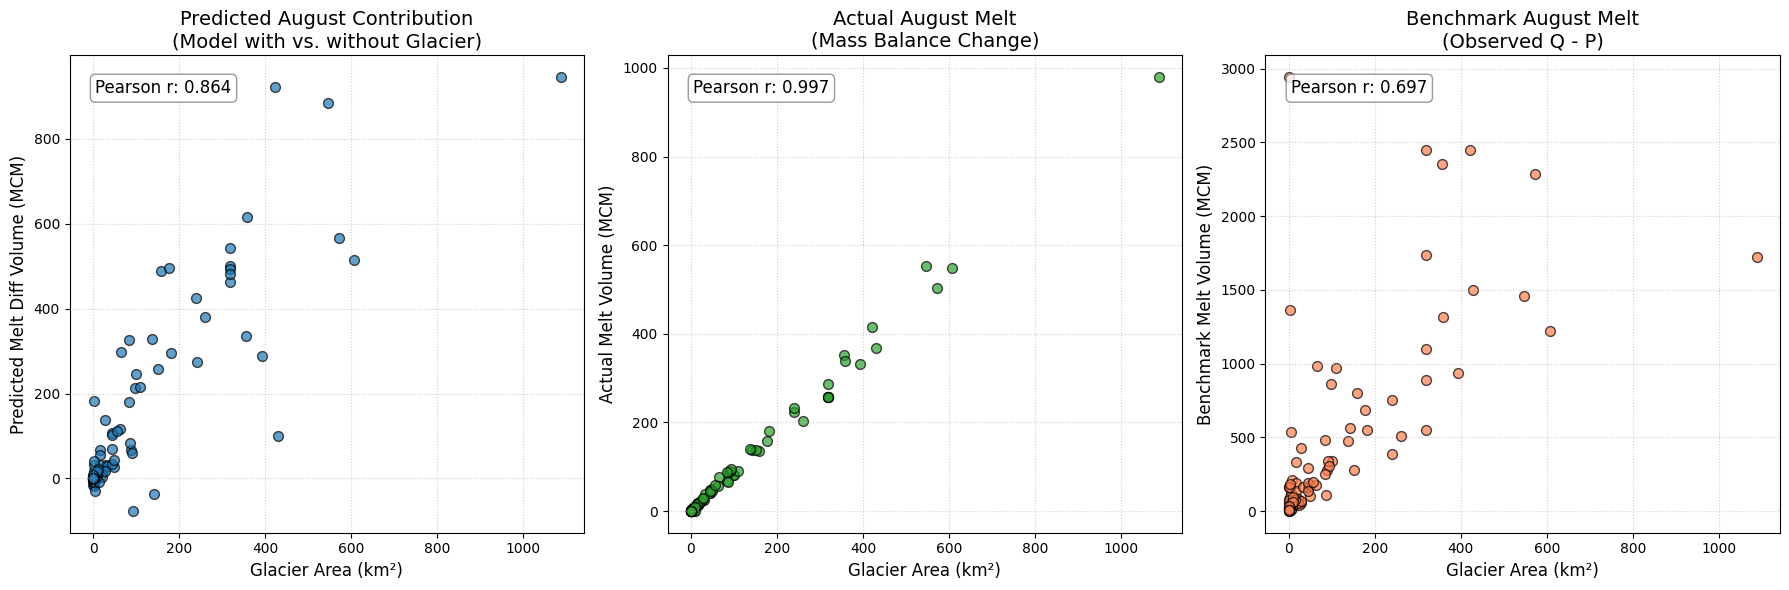

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from src.config import PROCESSED_DATA_DIR, CLIMATE_OUTPUT_DIR, OUTPUT_DATA_DIR

# =========================================================
# 1. Load Data
# =========================================================
# Load attributes to get glaciation percentage and area
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)

# Load Ground Truth Streamflow and Precipitation
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_prcp = pd.read_csv(CLIMATE_OUTPUT_DIR / "daily_precipitation.csv", index_col=0, parse_dates=True)

# Load mass balance (actual melt, negated to be positive, natively in MCM)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)

# Load predictions
df_pred = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
df_pred_no_glac = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions_no_glacier.csv", index_col=0, parse_dates=True)

# =========================================================
# 2. Filter, Convert, and Extract August Timeseries
# =========================================================
# Identify common glaciated stations (>0% glaciation)
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index
common_stations = glaciated_stations.intersection(df_obs.columns) \
                                    .intersection(df_prcp.columns) \
                                    .intersection(df_mb.columns) \
                                    .intersection(df_pred.columns) \
                                    .intersection(df_pred_no_glac.columns)

print(f"Analyzing {len(common_stations)} glaciated stations...")

# Filter data for these stations
df_obs = df_obs[common_stations]
df_prcp = df_prcp[common_stations]
df_mb = df_mb[common_stations]
df_pred = df_pred[common_stations]
df_pred_no_glac = df_pred_no_glac[common_stations]

# Convert ground truth streamflow and precipitation to mm/day
for station in common_stations:
    area_km2 = df_attr.loc[station, 'basin_area_km2'] 
    df_obs[station] = df_obs[station] * (86.4 / area_km2)
    df_prcp[station] = df_prcp[station] / area_km2

# --- Filter for August ---
df_obs_aug = df_obs[df_obs.index.month == 8]
df_prcp_aug = df_prcp[df_prcp.index.month == 8]
df_mb_aug = df_mb[df_mb.index.month == 8]

df_diff = df_pred - df_pred_no_glac
df_diff_aug = df_diff[df_diff.index.month == 8]

# --- Calculate Yearly August Sums ---
df_obs_aug_yearly = df_obs_aug.groupby(df_obs_aug.index.year).sum()
df_prcp_aug_yearly = df_prcp_aug.groupby(df_prcp_aug.index.year).sum()
df_mb_aug_yearly = df_mb_aug.groupby(df_mb_aug.index.year).sum()
df_diff_aug_yearly = df_diff_aug.groupby(df_diff_aug.index.year).sum()

# Benchmark Melt (Streamflow - Precipitation)
df_benchmark_yearly = df_obs_aug_yearly - df_prcp_aug_yearly

# =========================================================
# 3. Convert Units to Volume (MCM) & Calculate Means
# =========================================================
# Get basin areas for conversion
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# Actual is already MCM. Convert Predicted and Benchmark from mm to MCM
actual_mcm_yearly = df_mb_aug_yearly
pred_mcm_yearly = df_diff_aug_yearly * basin_areas * 0.001
bench_mcm_yearly = df_benchmark_yearly * basin_areas * 0.001

# Calculate the mean across all available years for each station
mean_pred_mcm = pred_mcm_yearly.mean()
mean_actual_mcm = actual_mcm_yearly.mean()
mean_bench_mcm = bench_mcm_yearly.mean()

# Extract Glacier Area for the X-axis
glac_area = df_attr.loc[common_stations, 'glacier_area_km2']

# =========================================================
# 4. Helper Function for Correlation & Masking
# =========================================================
def get_clean_data_and_corr(x_series, y_series):
    # Drop NaNs to ensure clean correlation calculation
    valid_mask = ~(np.isnan(x_series) | np.isnan(y_series))
    x_clean = x_series[valid_mask]
    y_clean = y_series[valid_mask]
    corr, p_value = stats.pearsonr(x_clean, y_clean)
    return x_clean, y_clean, corr, p_value

# =========================================================
# 5. Plotting
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

# Data pairs and settings for the 3 subplots
plot_configs = [
    {
        'ax': axes[0], 'y_data': mean_pred_mcm, 
        'color': 'tab:blue', 
        'title': 'Predicted August Contribution\n(Model with vs. without Glacier)',
        'ylabel': 'Predicted Melt Diff Volume (MCM)'
    },
    {
        'ax': axes[1], 'y_data': mean_actual_mcm, 
        'color': 'tab:green', 
        'title': 'Actual August Melt\n(Mass Balance Change)',
        'ylabel': 'Actual Melt Volume (MCM)'
    },
    {
        'ax': axes[2], 'y_data': mean_bench_mcm, 
        'color': 'coral', 
        'title': 'Benchmark August Melt\n(Observed Q - P)',
        'ylabel': 'Benchmark Melt Volume (MCM)'
    }
]

for config in plot_configs:
    ax = config['ax']
    x_clean, y_clean, corr, p_val = get_clean_data_and_corr(glac_area, config['y_data'])
    
    ax.scatter(x_clean, y_clean, color=config['color'], alpha=0.7, edgecolor='k', s=50)
    
    ax.set_title(config['title'], fontsize=14)
    ax.set_xlabel('Glacier Area (km²)', fontsize=12)
    ax.set_ylabel(config['ylabel'], fontsize=12)
    
    # Add correlation text box
    textstr = f'Pearson r: {corr:.3f}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Analyzing 95 glaciated stations (>0% glaciation)...

--- Average Error Metrics ---
Model Predicted Melt vs Actual:
  Mean Error (Bias):             +0.96 mm  |    +34.14 MCM
  Mean Absolute Error (MAE):     19.56 mm  |     79.19 MCM
  TOTAL Volumetric Bias:      +32434.71 MCM

Benchmark (Q-P) vs Actual:
  Mean Error (Bias):            +57.08 mm  |   +308.91 MCM
  Mean Absolute Error (MAE):     57.35 mm  |    309.91 MCM
  TOTAL Volumetric Bias:      +293463.81 MCM



C:\Users\tbwil\AppData\Local\Temp\ipykernel_25456\3288069347.py:71: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  df_snow_yearly = df_snow.resample('A-AUG').sum()


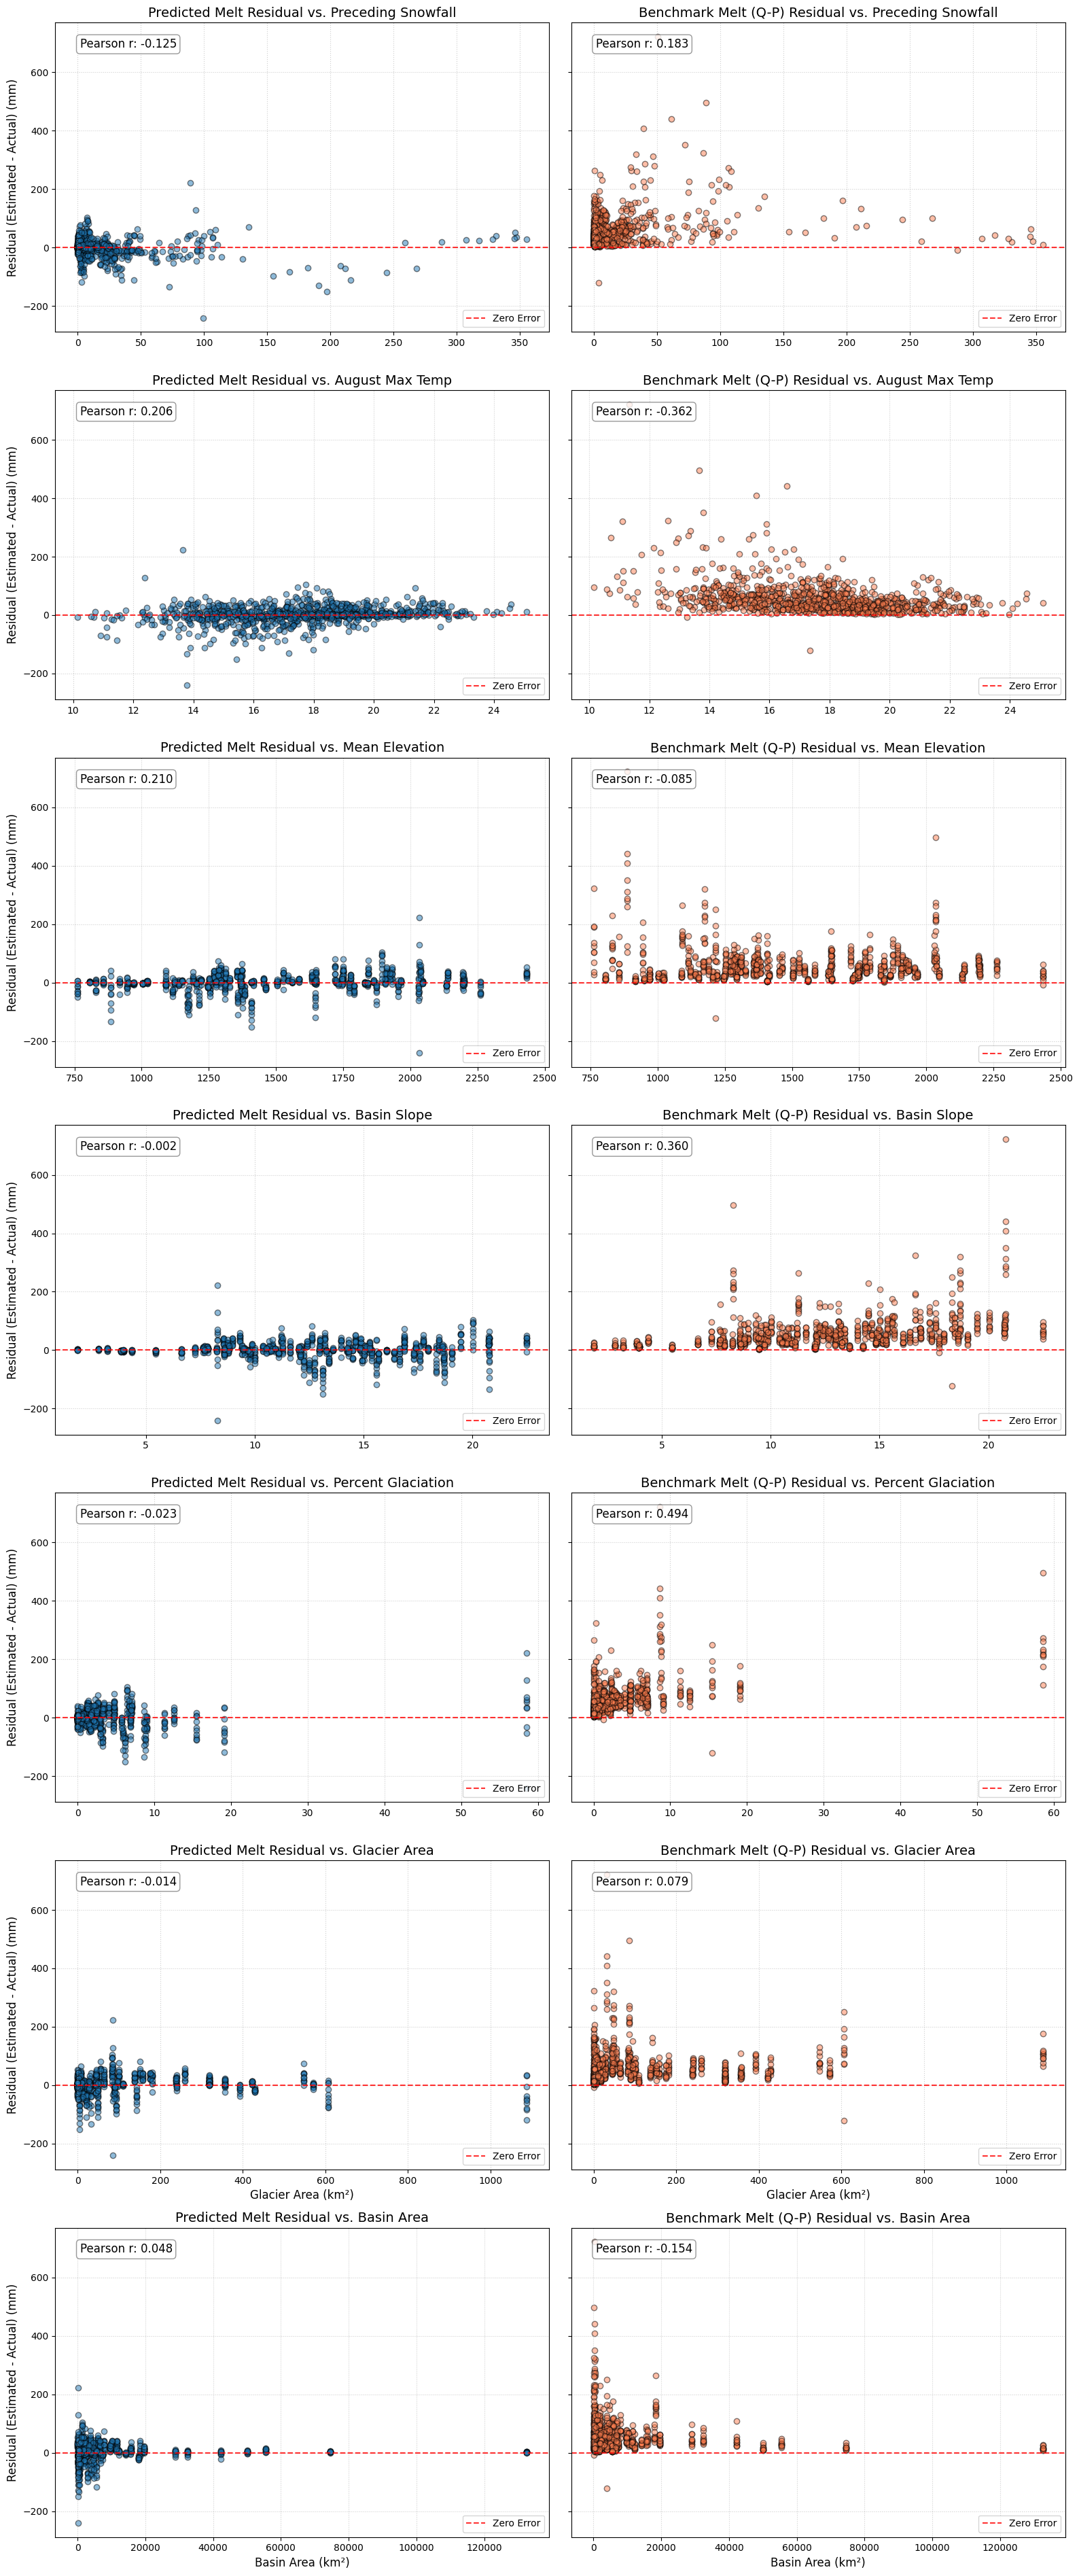

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from src.config import PROCESSED_DATA_DIR, CLIMATE_OUTPUT_DIR, OUTPUT_DATA_DIR

# =========================================================
# 1. Load Data
# =========================================================
# Load attributes
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)

# Load Hydromet & Climate Data
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_prcp = pd.read_csv(CLIMATE_OUTPUT_DIR / "daily_precipitation.csv", index_col=0, parse_dates=True)
df_snow = pd.read_csv(CLIMATE_OUTPUT_DIR / "daily_snowfall.csv", index_col=0, parse_dates=True)
df_tmax = pd.read_csv(CLIMATE_OUTPUT_DIR / "daily_temp_max.csv", index_col=0, parse_dates=True)

# Load Mass Balance (This is already in MCM)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)

# Load Predictions (These generate mm over the basin)
df_pred = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
df_pred_no_glac = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions_no_glacier.csv", index_col=0, parse_dates=True)

# =========================================================
# 2. Filter and Convert Units
# =========================================================
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0.0].index
common_stations = glaciated_stations.intersection(df_obs.columns) \
                                    .intersection(df_prcp.columns) \
                                    .intersection(df_snow.columns) \
                                    .intersection(df_tmax.columns) \
                                    .intersection(df_mb.columns) \
                                    .intersection(df_pred.columns) \
                                    .intersection(df_pred_no_glac.columns)

print(f"Analyzing {len(common_stations)} glaciated stations (>0% glaciation)...")

df_obs = df_obs[common_stations]
df_prcp = df_prcp[common_stations]
df_snow = df_snow[common_stations]
df_tmax = df_tmax[common_stations]
df_mb = df_mb[common_stations]
df_pred = df_pred[common_stations]
df_pred_no_glac = df_pred_no_glac[common_stations]

for station in common_stations:
    area_km2 = df_attr.loc[station, 'basin_area_km2'] 
    df_obs[station] = df_obs[station] * (86.4 / area_km2)
    df_prcp[station] = df_prcp[station] / area_km2
    df_snow[station] = df_snow[station] / area_km2

# =========================================================
# 3. Calculate Aggregations
# =========================================================
df_obs_aug = df_obs[df_obs.index.month == 8]
df_prcp_aug = df_prcp[df_prcp.index.month == 8]
df_mb_aug = df_mb[df_mb.index.month == 8]
df_diff_aug = (df_pred - df_pred_no_glac)[(df_pred.index.month == 8)]
df_tmax_aug = df_tmax[df_tmax.index.month == 8]

df_obs_aug_yearly = df_obs_aug.groupby(df_obs_aug.index.year).sum()
df_prcp_aug_yearly = df_prcp_aug.groupby(df_prcp_aug.index.year).sum()
df_mb_aug_yearly = df_mb_aug.groupby(df_mb_aug.index.year).sum()
df_diff_aug_yearly = df_diff_aug.groupby(df_diff_aug.index.year).sum()

df_tmax_aug_yearly = df_tmax_aug.groupby(df_tmax_aug.index.year).mean()
df_benchmark_yearly = df_obs_aug_yearly - df_prcp_aug_yearly

df_snow_yearly = df_snow.resample('A-AUG').sum()
df_snow_yearly.index = df_snow_yearly.index.year

# =========================================================
# 4. Correct Units, Calculate Residuals & Align Years
# =========================================================
common_years = df_mb_aug_yearly.index.intersection(df_benchmark_yearly.index) \
                                     .intersection(df_diff_aug_yearly.index) \
                                     .intersection(df_snow_yearly.index) \
                                     .intersection(df_tmax_aug_yearly.index)
                                     
df_mb_aug_yearly = df_mb_aug_yearly.loc[common_years]
df_benchmark_yearly = df_benchmark_yearly.loc[common_years]
df_diff_aug_yearly = df_diff_aug_yearly.loc[common_years]
df_snow_yearly = df_snow_yearly.loc[common_years]
df_tmax_aug_yearly = df_tmax_aug_yearly.loc[common_years]

basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# --- Calculate Volumetric Error (MCM) ---
# Actual is already MCM. We calculate Predicted and Benchmark MCM by multiplying 
# their basin-wide depth (mm) by the basin area (km2) and converting (* 0.001)
actual_mcm = df_mb_aug_yearly
pred_mcm = df_diff_aug_yearly * basin_areas * 0.001
bench_mcm = df_benchmark_yearly * basin_areas * 0.001

res_pred_mcm = pred_mcm - actual_mcm
res_bench_mcm = bench_mcm - actual_mcm

# --- Calculate Depth Error (mm) ---
# To compare actual melt depth against basin-wide predicted depth, we must convert 
# actual MCM to a basin-wide equivalent mm: (MCM / Basin Area) * 1000
actual_mm_basin_equiv = (actual_mcm * 1000).div(basin_areas, axis=1)

res_pred = df_diff_aug_yearly - actual_mm_basin_equiv
res_bench = df_benchmark_yearly - actual_mm_basin_equiv

# Print Error Metrics
print("\n--- Average Error Metrics ---")
print("Model Predicted Melt vs Actual:")
print(f"  Mean Error (Bias):          {np.nanmean(res_pred):+8.2f} mm  |  {np.nanmean(res_pred_mcm):+8.2f} MCM")
print(f"  Mean Absolute Error (MAE):  {np.nanmean(np.abs(res_pred)):8.2f} mm  |  {np.nanmean(np.abs(res_pred_mcm)):8.2f} MCM")
print(f"  TOTAL Volumetric Bias:      {np.nansum(pred_mcm) - np.nansum(actual_mcm):+8.2f} MCM")

print("\nBenchmark (Q-P) vs Actual:")
print(f"  Mean Error (Bias):          {np.nanmean(res_bench):+8.2f} mm  |  {np.nanmean(res_bench_mcm):+8.2f} MCM")
print(f"  Mean Absolute Error (MAE):  {np.nanmean(np.abs(res_bench)):8.2f} mm  |  {np.nanmean(np.abs(res_bench_mcm)):8.2f} MCM")
print(f"  TOTAL Volumetric Bias:      {np.nansum(bench_mcm) - np.nansum(actual_mcm):+8.2f} MCM\n")

# Replicate Static Attributes for plotting
def replicate_attr(col_name):
    return pd.DataFrame(np.tile(df_attr.loc[common_stations, col_name].values, (len(common_years), 1)), 
                        index=common_years, columns=common_stations)

df_elev_yearly = replicate_attr('mean_elev')
df_slope_yearly = replicate_attr('mean_slope')
df_glac_pct_yearly = replicate_attr('glacier_pct')
df_glac_area_yearly = replicate_attr('glacier_area_km2')
df_basin_area_yearly = replicate_attr('basin_area_km2')

# =========================================================
# 5. Prepare Data for Plotting (Flatten Arrays)
# =========================================================
def get_clean_flat_data(x_df, y_df):
    x_flat = x_df.values.flatten()
    y_flat = y_df.values.flatten()
    valid_mask = ~(np.isnan(x_flat) | np.isnan(y_flat))
    x_clean = x_flat[valid_mask]
    y_clean = y_flat[valid_mask]
    corr, _ = stats.pearsonr(x_clean, y_clean)
    return x_clean, y_clean, corr

# Get data for the plots (using the depth residuals in mm)
x_snow_pred, y_res_pred_snow, c_snow_pred = get_clean_flat_data(df_snow_yearly, res_pred)
x_snow_bench, y_res_bench_snow, c_snow_bench = get_clean_flat_data(df_snow_yearly, res_bench)

x_tmax_pred, y_res_pred_tmax, c_tmax_pred = get_clean_flat_data(df_tmax_aug_yearly, res_pred)
x_tmax_bench, y_res_bench_tmax, c_tmax_bench = get_clean_flat_data(df_tmax_aug_yearly, res_bench)

x_elev_pred, y_res_pred_elev, c_elev_pred = get_clean_flat_data(df_elev_yearly, res_pred)
x_elev_bench, y_res_bench_elev, c_elev_bench = get_clean_flat_data(df_elev_yearly, res_bench)

x_slope_pred, y_res_pred_slope, c_slope_pred = get_clean_flat_data(df_slope_yearly, res_pred)
x_slope_bench, y_res_bench_slope, c_slope_bench = get_clean_flat_data(df_slope_yearly, res_bench)

x_glac_pct_pred, y_res_pred_glac_pct, c_glac_pct_pred = get_clean_flat_data(df_glac_pct_yearly, res_pred)
x_glac_pct_bench, y_res_bench_glac_pct, c_glac_pct_bench = get_clean_flat_data(df_glac_pct_yearly, res_bench)

x_glac_area_pred, y_res_pred_glac_area, c_glac_area_pred = get_clean_flat_data(df_glac_area_yearly, res_pred)
x_glac_area_bench, y_res_bench_glac_area, c_glac_area_bench = get_clean_flat_data(df_glac_area_yearly, res_bench)

x_basin_area_pred, y_res_pred_basin_area, c_basin_area_pred = get_clean_flat_data(df_basin_area_yearly, res_pred)
x_basin_area_bench, y_res_bench_basin_area, c_basin_area_bench = get_clean_flat_data(df_basin_area_yearly, res_bench)

# =========================================================
# 6. Plotting
# =========================================================
fig, axes = plt.subplots(7, 2, figsize=(16, 38), sharey=True)

props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
color_pred = 'tab:blue'
color_bench = 'coral'

def plot_subplot(ax, x_data, y_data, corr, color, title, xlabel):
    ax.scatter(x_data, y_data, color=color, alpha=0.5, edgecolor='k')
    ax.set_title(title, fontsize=14)
    if xlabel: ax.set_xlabel(xlabel, fontsize=12)
    ax.text(0.05, 0.95, f'Pearson r: {corr:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)

# --- ROW 1: SNOWFALL ---
plot_subplot(axes[0,0], x_snow_pred, y_res_pred_snow, c_snow_pred, color_pred, 'Predicted Melt Residual vs. Preceding Snowfall', '')
axes[0,0].set_ylabel('Residual (Estimated - Actual) (mm)', fontsize=12)
plot_subplot(axes[0,1], x_snow_bench, y_res_bench_snow, c_snow_bench, color_bench, 'Benchmark Melt (Q-P) Residual vs. Preceding Snowfall', '')

# --- ROW 2: TEMPERATURE ---
plot_subplot(axes[1,0], x_tmax_pred, y_res_pred_tmax, c_tmax_pred, color_pred, 'Predicted Melt Residual vs. August Max Temp', '')
axes[1,0].set_ylabel('Residual (Estimated - Actual) (mm)', fontsize=12)
plot_subplot(axes[1,1], x_tmax_bench, y_res_bench_tmax, c_tmax_bench, color_bench, 'Benchmark Melt (Q-P) Residual vs. August Max Temp', '')

# --- ROW 3: ELEVATION ---
plot_subplot(axes[2,0], x_elev_pred, y_res_pred_elev, c_elev_pred, color_pred, 'Predicted Melt Residual vs. Mean Elevation', '')
axes[2,0].set_ylabel('Residual (Estimated - Actual) (mm)', fontsize=12)
plot_subplot(axes[2,1], x_elev_bench, y_res_bench_elev, c_elev_bench, color_bench, 'Benchmark Melt (Q-P) Residual vs. Mean Elevation', '')

# --- ROW 4: SLOPE ---
plot_subplot(axes[3,0], x_slope_pred, y_res_pred_slope, c_slope_pred, color_pred, 'Predicted Melt Residual vs. Basin Slope', '')
axes[3,0].set_ylabel('Residual (Estimated - Actual) (mm)', fontsize=12)
plot_subplot(axes[3,1], x_slope_bench, y_res_bench_slope, c_slope_bench, color_bench, 'Benchmark Melt (Q-P) Residual vs. Basin Slope', '')

# --- ROW 5: GLACIATION PCT ---
plot_subplot(axes[4,0], x_glac_pct_pred, y_res_pred_glac_pct, c_glac_pct_pred, color_pred, 'Predicted Melt Residual vs. Percent Glaciation', '')
axes[4,0].set_ylabel('Residual (Estimated - Actual) (mm)', fontsize=12)
plot_subplot(axes[4,1], x_glac_pct_bench, y_res_bench_glac_pct, c_glac_pct_bench, color_bench, 'Benchmark Melt (Q-P) Residual vs. Percent Glaciation', '')

# --- ROW 6: GLACIER AREA ---
plot_subplot(axes[5,0], x_glac_area_pred, y_res_pred_glac_area, c_glac_area_pred, color_pred, 'Predicted Melt Residual vs. Glacier Area', 'Glacier Area (km²)')
axes[5,0].set_ylabel('Residual (Estimated - Actual) (mm)', fontsize=12)
plot_subplot(axes[5,1], x_glac_area_bench, y_res_bench_glac_area, c_glac_area_bench, color_bench, 'Benchmark Melt (Q-P) Residual vs. Glacier Area', 'Glacier Area (km²)')

# --- ROW 7: BASIN AREA ---
plot_subplot(axes[6,0], x_basin_area_pred, y_res_pred_basin_area, c_basin_area_pred, color_pred, 'Predicted Melt Residual vs. Basin Area', 'Basin Area (km²)')
axes[6,0].set_ylabel('Residual (Estimated - Actual) (mm)', fontsize=12)
plot_subplot(axes[6,1], x_basin_area_bench, y_res_bench_basin_area, c_basin_area_bench, color_bench, 'Benchmark Melt (Q-P) Residual vs. Basin Area', 'Basin Area (km²)')

# Add reference lines and grid to all
for ax in axes.flatten():
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Zero Error')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

Aggregating 75 glaciated stations across regions...


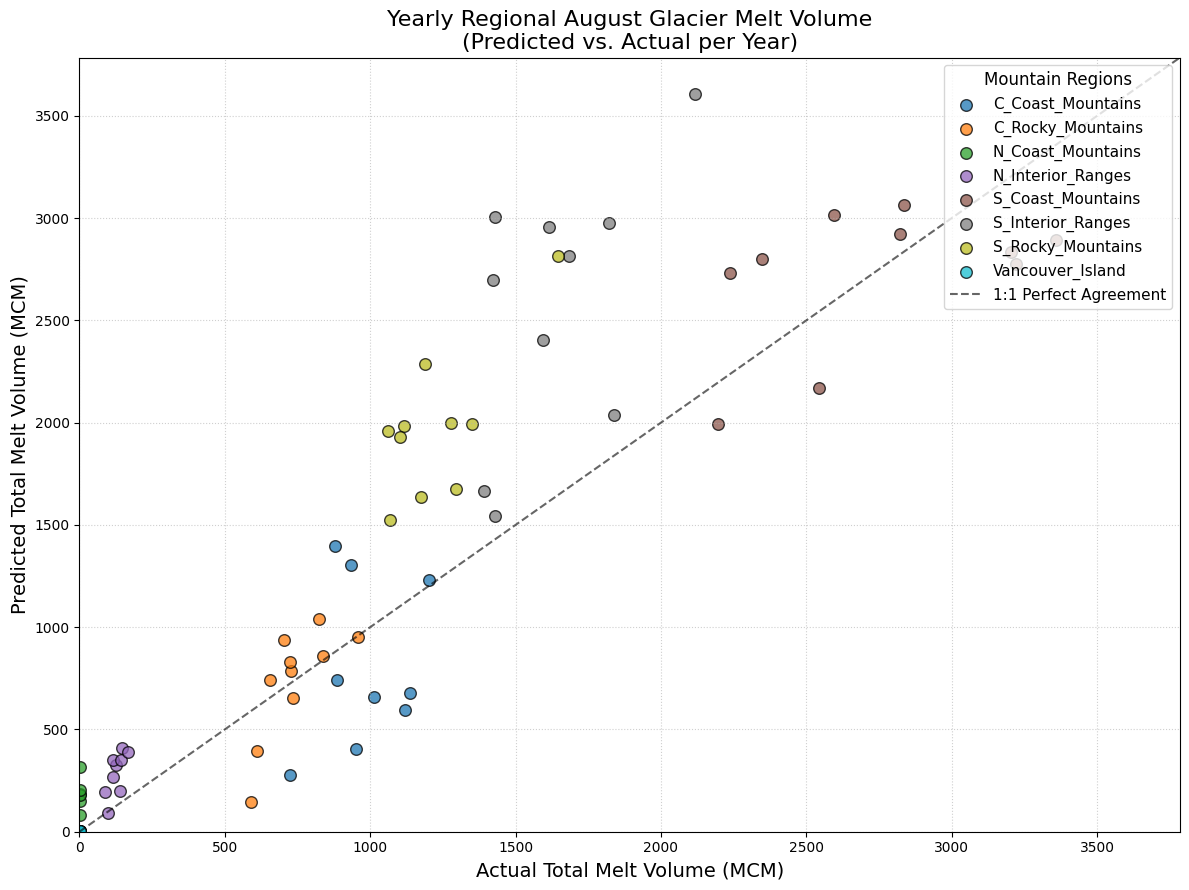

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, RAW_DATA_DIR

# =========================================================
# 1. Define Shapefile Region Column
# =========================================================
# CHANGE THIS to the actual column name you found in the shapefile
REGION_COL = 'Name' 

# =========================================================
# 2. Load Data
# =========================================================
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_meta = pd.read_csv(RAW_DATA_DIR / "station_metadata.csv", index_col=0)

# Negate mass balance to make melt positive (Already in MCM)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)

df_pred = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
df_pred_no_glac = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions_no_glacier.csv", index_col=0, parse_dates=True)

gdf_regions = gpd.read_file(RAW_DATA_DIR / "mass_balance/subregions_shapefiles/bca_glacier_regions.shp")

# =========================================================
# 3. Spatial Join: Assign Stations to Regions
# =========================================================
geometry = [Point(xy) for xy in zip(df_meta['Longitude'], df_meta['Latitude'])]
gdf_stations = gpd.GeoDataFrame(df_meta, geometry=geometry, crs="EPSG:4326")
gdf_stations = gdf_stations.to_crs(gdf_regions.crs)

stations_in_regions = gpd.sjoin(gdf_stations, gdf_regions, how="inner", predicate="intersects")
matched_stations = stations_in_regions.index

# =========================================================
# 4. Filter and Calculate August Depths/Volumes per Year
# =========================================================
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index
common_stations = glaciated_stations.intersection(df_mb.columns) \
                                    .intersection(df_pred.columns) \
                                    .intersection(df_pred_no_glac.columns) \
                                    .intersection(matched_stations)

print(f"Aggregating {len(common_stations)} glaciated stations across regions...")

df_mb = df_mb[common_stations]
df_diff = (df_pred[common_stations] - df_pred_no_glac[common_stations])

# Extract August and calculate yearly sums
df_mb_aug_yearly = df_mb[df_mb.index.month == 8].groupby(df_mb[df_mb.index.month == 8].index.year).sum()
df_diff_aug_yearly = df_diff[df_diff.index.month == 8].groupby(df_diff[df_diff.index.month == 8].index.year).sum()

# Align the years between actual and predicted
common_years = df_mb_aug_yearly.index.intersection(df_diff_aug_yearly.index)
df_mb_aug_yearly = df_mb_aug_yearly.loc[common_years]
df_diff_aug_yearly = df_diff_aug_yearly.loc[common_years]

# Name the index so we can melt the dataframe cleanly later
df_mb_aug_yearly.index.name = 'Year'
df_diff_aug_yearly.index.name = 'Year'

# =========================================================
# 5. Correct Units to Volumes (MCM) per Year
# =========================================================
# Extract basin areas for the prediction conversion
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# Actual is already in MCM
actual_vol_mcm = df_mb_aug_yearly 

# Predicted is in mm spread over the basin area, so we convert to MCM
predicted_vol_mcm = df_diff_aug_yearly * basin_areas * 0.001

# Melt DataFrames to long format: columns become ['Year', 'Station', 'Volume']
actual_long = actual_vol_mcm.reset_index().melt(id_vars='Year', var_name='Station', value_name='Actual_Volume_MCM')
predicted_long = predicted_vol_mcm.reset_index().melt(id_vars='Year', var_name='Station', value_name='Predicted_Volume_MCM')

# Merge actual and predicted
df_volumes = pd.merge(actual_long, predicted_long, on=['Year', 'Station'])

# Map the region string to each station
df_volumes['Region'] = df_volumes['Station'].map(stations_in_regions[REGION_COL])

# =========================================================
# 6. Aggregate by Region AND Year
# =========================================================
# Sum the volumes for all stations within each region, for each specific year
df_regional_yearly = df_volumes.groupby(['Region', 'Year'])[['Actual_Volume_MCM', 'Predicted_Volume_MCM']].sum().reset_index()

# =========================================================
# 7. Plotting
# =========================================================
fig, ax = plt.subplots(figsize=(12, 9))

unique_regions = df_regional_yearly['Region'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_regions)))

# Plot each region
for i, region in enumerate(unique_regions):
    region_data = df_regional_yearly[df_regional_yearly['Region'] == region]
    
    ax.scatter(region_data['Actual_Volume_MCM'], region_data['Predicted_Volume_MCM'], 
               color=colors[i], s=70, edgecolor='black', alpha=0.75, label=region)

# Add a 1:1 Reference Line (Perfect Agreement)
max_val = max(df_regional_yearly['Actual_Volume_MCM'].max(), df_regional_yearly['Predicted_Volume_MCM'].max())
# Extend the line slightly past the max value for aesthetics
line_max = max_val * 1.05 
ax.plot([0, line_max], [0, line_max], 'k--', alpha=0.6, label='1:1 Perfect Agreement')

# Formatting
ax.set_title('Yearly Regional August Glacier Melt Volume\n(Predicted vs. Actual per Year)', fontsize=16)
ax.set_xlabel('Actual Total Melt Volume (MCM)', fontsize=14)
ax.set_ylabel('Predicted Total Melt Volume (MCM)', fontsize=14)

# Force axes to start at 0
ax.set_xlim(left=0, right=line_max)
ax.set_ylim(bottom=0, top=line_max)

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(title='Mountain Regions', fontsize=11, title_fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

Aggregating 95 glaciated stations across regions...

--- Pearson Correlation Over Time (By Region) ---
C_Coast_Mountains         | r = +0.566  (p-value: 8.787e-02)
C_Rocky_Mountains         | r = +0.495  (p-value: 1.462e-01)
N_Coast_Mountains         | r = +0.425  (p-value: 2.209e-01)
N_Interior_Ranges         | r = +0.684  (p-value: 2.927e-02)
S_Coast_Mountains         | r = +0.649  (p-value: 4.242e-02)
S_Interior_Ranges         | r = +0.617  (p-value: 5.737e-02)
S_Rocky_Mountains         | r = +0.699  (p-value: 2.458e-02)
Vancouver_Island          | r = +0.248  (p-value: 4.888e-01)

--- Total Aggregated Correlation ---
ALL REGIONS COMBINED      | r = +0.698  (p-value: 2.492e-02)



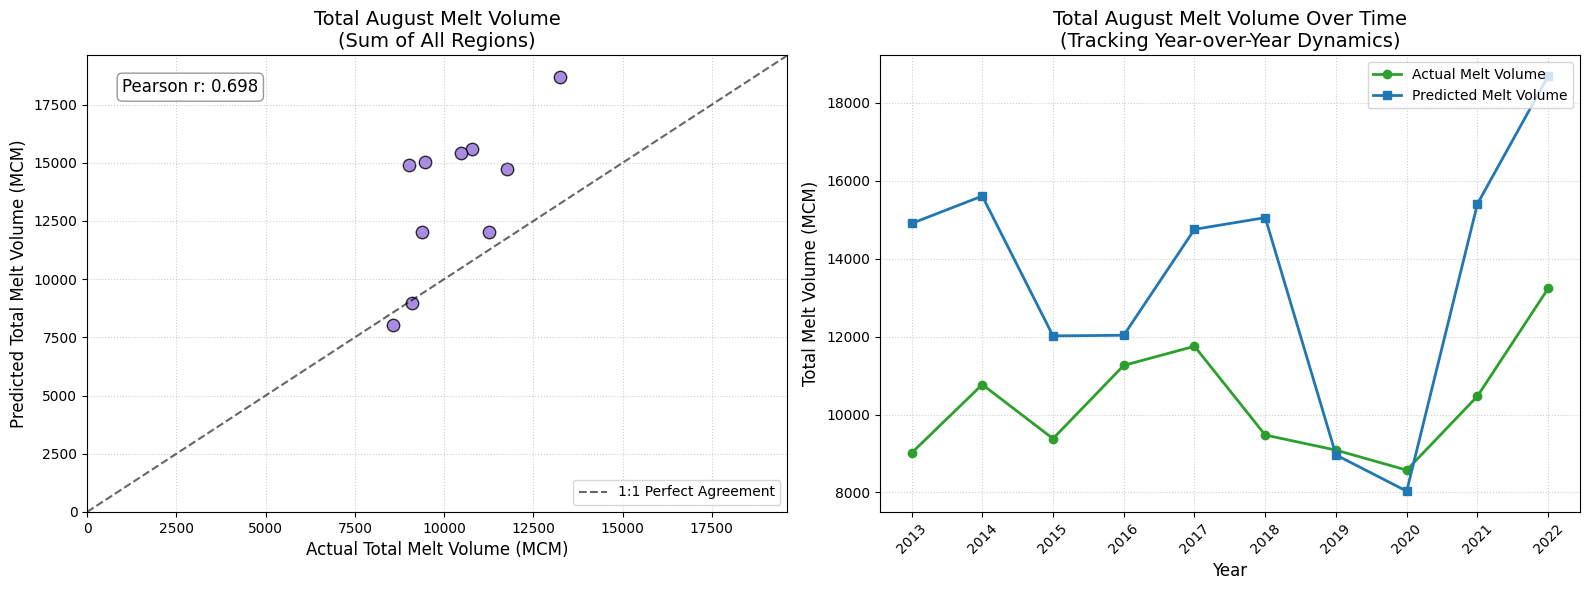

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import geopandas as gpd
from shapely.geometry import Point
import warnings
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, RAW_DATA_DIR

# =========================================================
# 1. Define Shapefile Region Column
# =========================================================
REGION_COL = 'Name' 

# =========================================================
# 2. Load Data
# =========================================================
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_meta = pd.read_csv(RAW_DATA_DIR / "station_metadata.csv", index_col=0)

# Negate mass balance to make melt positive (Units: MCM)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)

# Predictions (Units: mm over the basin)
df_pred = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
df_pred_no_glac = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions_no_glacier.csv", index_col=0, parse_dates=True)

gdf_regions = gpd.read_file(RAW_DATA_DIR / "mass_balance/subregions_shapefiles/bca_glacier_regions.shp")

# =========================================================
# 3. Spatial Join: Assign Stations to NEAREST Region
# =========================================================
geometry = [Point(xy) for xy in zip(df_meta['Longitude'], df_meta['Latitude'])]
gdf_stations = gpd.GeoDataFrame(df_meta, geometry=geometry, crs="EPSG:4326")
gdf_stations = gdf_stations.to_crs(gdf_regions.crs)

# Use sjoin_nearest to snap unmatched stations to the closest region
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    stations_in_regions = gpd.sjoin_nearest(gdf_stations, gdf_regions, how="left", distance_col="dist_to_region")

matched_stations = stations_in_regions.index

# =========================================================
# 4. Filter and Calculate August Sums per Year
# =========================================================
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index
common_stations = glaciated_stations.intersection(df_mb.columns) \
                                    .intersection(df_pred.columns) \
                                    .intersection(df_pred_no_glac.columns) \
                                    .intersection(matched_stations)

print(f"Aggregating {len(common_stations)} glaciated stations across regions...")

df_mb = df_mb[common_stations]
df_diff = (df_pred[common_stations] - df_pred_no_glac[common_stations])

# Extract August and calculate yearly sums
df_mb_aug_yearly = df_mb[df_mb.index.month == 8].groupby(df_mb[df_mb.index.month == 8].index.year).sum()
df_diff_aug_yearly = df_diff[df_diff.index.month == 8].groupby(df_diff[df_diff.index.month == 8].index.year).sum()

# Align the years between actual and predicted
common_years = df_mb_aug_yearly.index.intersection(df_diff_aug_yearly.index)
df_mb_aug_yearly = df_mb_aug_yearly.loc[common_years]
df_diff_aug_yearly = df_diff_aug_yearly.loc[common_years]

df_mb_aug_yearly.index.name = 'Year'
df_diff_aug_yearly.index.name = 'Year'

# =========================================================
# 5. Convert Depths to Volumes (MCM) per Year
# =========================================================
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# --- The Unit Fix ---
# Actual Mass Balance is ALREADY in MCM, so no conversion is needed
actual_vol_mcm = df_mb_aug_yearly 
# Predicted streamflow difference is in mm, so we convert to volume: Depth (mm) * Area (km^2) * 0.001 = MCM
predicted_vol_mcm = df_diff_aug_yearly * basin_areas * 0.001

# Melt DataFrames to long format
actual_long = actual_vol_mcm.reset_index().melt(id_vars='Year', var_name='Station', value_name='Actual_Volume_MCM')
predicted_long = predicted_vol_mcm.reset_index().melt(id_vars='Year', var_name='Station', value_name='Predicted_Volume_MCM')

df_volumes = pd.merge(actual_long, predicted_long, on=['Year', 'Station'])

# Handle potential duplicate matches if a station is perfectly equidistant between two regions
# by taking the first match using ~df_volumes.index.duplicated()
df_volumes['Region'] = df_volumes['Station'].map(stations_in_regions[REGION_COL][~stations_in_regions.index.duplicated(keep='first')])

# =========================================================
# 6. Aggregate by Region AND Calculate Correlations
# =========================================================
df_regional_yearly = df_volumes.groupby(['Region', 'Year'])[['Actual_Volume_MCM', 'Predicted_Volume_MCM']].sum().reset_index()

print("\n--- Pearson Correlation Over Time (By Region) ---")
unique_regions = df_regional_yearly['Region'].unique()
for region in unique_regions:
    reg_data = df_regional_yearly[df_regional_yearly['Region'] == region]
    if len(reg_data) > 3: # Need a few data points to calculate a meaningful correlation
        r, p = stats.pearsonr(reg_data['Actual_Volume_MCM'], reg_data['Predicted_Volume_MCM'])
        print(f"{str(region):25} | r = {r:+.3f}  (p-value: {p:.3e})")
    else:
        print(f"{str(region):25} | Not enough years of data.")

# =========================================================
# 7. Aggregate Total Melt (All Regions Combined)
# =========================================================
df_total_yearly = df_regional_yearly.groupby('Year')[['Actual_Volume_MCM', 'Predicted_Volume_MCM']].sum()

# Calculate global correlation
r_total, p_total = stats.pearsonr(df_total_yearly['Actual_Volume_MCM'], df_total_yearly['Predicted_Volume_MCM'])
print("\n--- Total Aggregated Correlation ---")
print(f"ALL REGIONS COMBINED      | r = {r_total:+.3f}  (p-value: {p_total:.3e})\n")

# =========================================================
# 8. Plotting Total Aggregated Melt Over Time
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left Plot: Scatter of Yearly Totals ---
axes[0].scatter(df_total_yearly['Actual_Volume_MCM'], df_total_yearly['Predicted_Volume_MCM'], 
                color='mediumpurple', s=80, alpha=0.8, edgecolor='k')

# 1:1 Reference Line
max_val = max(df_total_yearly['Actual_Volume_MCM'].max(), df_total_yearly['Predicted_Volume_MCM'].max())
line_max = max_val * 1.05 
axes[0].plot([0, line_max], [0, line_max], 'k--', alpha=0.6, label='1:1 Perfect Agreement')

axes[0].set_title('Total August Melt Volume\n(Sum of All Regions)', fontsize=14)
axes[0].set_xlabel('Actual Total Melt Volume (MCM)', fontsize=12)
axes[0].set_ylabel('Predicted Total Melt Volume (MCM)', fontsize=12)

axes[0].set_xlim(0, line_max)
axes[0].set_ylim(0, line_max)

# Add correlation text box
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
axes[0].text(0.05, 0.95, f'Pearson r: {r_total:.3f}', transform=axes[0].transAxes, 
             fontsize=12, verticalalignment='top', bbox=props)

axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

# --- Right Plot: Timeseries Plot ---
axes[1].plot(df_total_yearly.index, df_total_yearly['Actual_Volume_MCM'], 
             marker='o', linestyle='-', color='tab:green', linewidth=2, label='Actual Melt Volume', markersize=6)
axes[1].plot(df_total_yearly.index, df_total_yearly['Predicted_Volume_MCM'], 
             marker='s', linestyle='-', color='tab:blue', linewidth=2, label='Predicted Melt Volume', markersize=6)

axes[1].set_title('Total August Melt Volume Over Time\n(Tracking Year-over-Year Dynamics)', fontsize=14)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Total Melt Volume (MCM)', fontsize=12)

# Ensure the x-axis ticks are integers (years)
axes[1].set_xticks(df_total_yearly.index)
axes[1].tick_params(axis='x', rotation=45)

axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()